# CNN-only preprocessing and multi-channel input comparison for direct vector regression

This notebook trains **CNN-only** direct raster-to-vector models and compares how different preprocessing representations affect vector output.

The learned method is always the CNN. The comparison now includes two input strategies:

1. **Single-preprocessing CNNs**: train one CNN per preprocessing representation.
2. **Multi-channel CNN**: train one CNN that receives several preprocessing representations of the same image stacked as separate input channels.

Skeletonization is only one optional preprocessing representation. It is not assumed to happen before the comparison starts.


In [1]:
import random
import math
from pathlib import Path
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# New data every time by default.
SEED = None
if SEED is not None:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

IMG_SIZE = 128
MAX_VECTORS = 5
LINE_WIDTH = 1

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
# New folder so this version does not overwrite/mix with earlier comparison outputs.
OUTPUT_FOLDER_NAME = "cnn_preprocess_multichannel_comparison_results"

# ------------------------------------------------------------
# Fast-run controls
# ------------------------------------------------------------
# These are intentionally small because the notebook can train several CNNs.
# Increase them later when the CNN/preprocessing comparison is behaving correctly.
N_TRAIN_IMAGES = 6000
N_TEST = 1200

PATCH_SIZE = 9
PATCH_RADIUS = PATCH_SIZE // 2
JUNCTION_RADIUS = 2

BATCH_SIZE = 128
CNN_EPOCHS = 10
LEARNING_RATE = 3e-4

# Controls the final vector cleanup.
MIN_VECTOR_LENGTH = 2.0
MAX_MERGE_PASSES = 2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print({
    'OUTPUT_FOLDER_NAME': OUTPUT_FOLDER_NAME,
    'N_TRAIN_IMAGES': N_TRAIN_IMAGES,
    'N_TEST': N_TEST,
    'BATCH_SIZE': BATCH_SIZE,
    'CNN_EPOCHS': CNN_EPOCHS,
    'LEARNING_RATE': LEARNING_RATE,
})


Device: cpu
{'OUTPUT_FOLDER_NAME': 'cnn_preprocess_multichannel_comparison_results', 'N_TRAIN_IMAGES': 6000, 'N_TEST': 1200, 'BATCH_SIZE': 128, 'CNN_EPOCHS': 10, 'LEARNING_RATE': 0.0003}


## Engineering drawing geometry configuration

These controls make the synthetic data and the final evaluation prefer engineering-style geometry: whole-degree angles, whole-pixel lengths, and stronger weighting for 90°, then 45°, 60°, 30°, and 10° angle families.


In [2]:
# Engineering drawing geometry controls
# These weights are deliberately easy to edit.
# A higher weight means mistakes on that angle family matter more, and data generation samples it more often.
GEOMETRY_CONFIG = {
    "angle_unit_deg": 1,          # all angles are rounded to whole degrees
    "length_unit_px": 1,          # all lengths are rounded to whole pixels
    "angle_unit_weights": {
        90: 5.0,                  # strongest preference: horizontal/vertical/right-angle work
        45: 3.0,
        60: 2.0,
        30: 1.5,
        10: 1.0,
        1: 0.25,                  # fallback: any whole-degree angle
    },
    "line_angle_tolerance_deg": 5.0,
    "junction_angle_tolerance_deg": 5.0,
    "length_tolerance_ratio": 0.15,
    "score_weights": {
        "line_geometry": 0.45,
        "total_length": 0.20,
        "junction_angles": 0.25,
        "vector_count": 0.10,
    },
}


def snap_angle_deg(angle_deg, unit_deg=None):
    """Snap an undirected line angle to the configured angle unit."""
    if unit_deg is None:
        unit_deg = GEOMETRY_CONFIG["angle_unit_deg"]
    return (round(angle_deg / unit_deg) * unit_deg) % 180


def snap_length_px(length_px, unit_px=None):
    """Snap a vector length to the configured pixel unit."""
    if unit_px is None:
        unit_px = GEOMETRY_CONFIG["length_unit_px"]
    return max(unit_px, round(length_px / unit_px) * unit_px)


def sample_weighted_angle_deg(config=GEOMETRY_CONFIG):
    """Sample a whole-degree engineering angle using the configured angle-family weights."""
    units = list(config["angle_unit_weights"].keys())
    weights = list(config["angle_unit_weights"].values())
    chosen_unit = random.choices(units, weights=weights, k=1)[0]

    # For line geometry, 0 and 180 degrees describe the same orientation.
    # We later add 180 randomly so the vector can point either way.
    if chosen_unit <= 1:
        base = random.randint(0, 179)
    else:
        candidates = list(range(0, 180, chosen_unit))
        base = random.choice(candidates)

    directed_angle = base + random.choice([0, 180])
    return round(directed_angle / config["angle_unit_deg"]) * config["angle_unit_deg"]


## 1. Synthetic vector data

Synthetic generator is changed here:

- line endpoints are integer pixel-centre grid points, from `0` to `IMG_SIZE - 1`;
- line direction is sampled from weighted engineering angle families, highest priority first: 90°, 45°, 60°, 30°;
- stroke weight varies per line between 0.5 and 3 pixels;
- dataset size, number of random items per image, stroke fading, and raster noise are editable in `SYNTHETIC_DATA_CONFIG`.


(6000, 128, 128) 6000
Synthetic data controls:
{'n_train_images': 6000, 'n_test_images': 1200, 'min_items_per_image': 1, 'max_items_per_image': 5, 'min_line_length_px': 12, 'margin_px': 4, 'line_width_range_px': (0.5, 3.0), 'stroke_fade_range': (0.9, 1.0), 'raster_noise_std': 0.0, 'angle_family_weights': {90: 8.0, 45: 4.0, 60: 2.0, 30: 1.0}, 'angle_rounding_deg': 1, 'max_line_generation_attempts': 1000}

Example line styles for first training image:
  line 0: {'width_px': 1.521, 'darkness': 0.971, 'angle_family': 90, 'target_angle_deg': 0, 'actual_angle_deg': 0.0}
  line 1: {'width_px': 0.954, 'darkness': 0.98, 'angle_family': 60, 'target_angle_deg': 60, 'actual_angle_deg': 59.676}


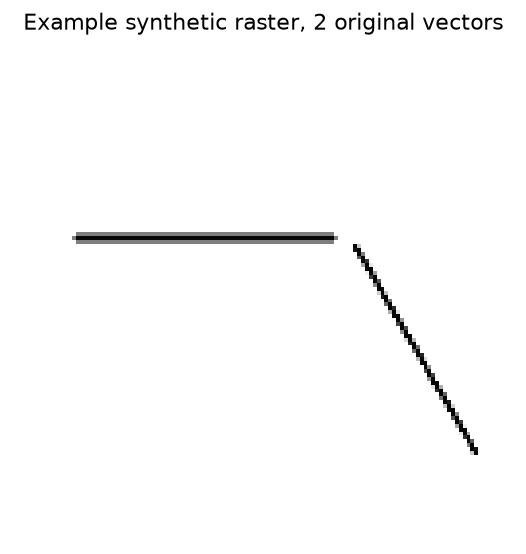

In [3]:
def clip_point(x, y, img_size=IMG_SIZE):
    """Clip a point to the valid pixel-centre grid: 0 ... img_size - 1."""
    return int(np.clip(round(x), 0, img_size - 1)), int(np.clip(round(y), 0, img_size - 1))


# Synthetic-data controls.
# Edit only this dictionary when you want more/fewer examples, more/fewer lines,
# more/less stroke fade, or more/less raster noise.
SYNTHETIC_DATA_CONFIG = {
    "n_train_images": N_TRAIN_IMAGES,   # number of random training drawings to create
    "n_test_images": N_TEST,            # number of random test drawings to create

    "min_items_per_image": 1,           # minimum random line items in one drawing
    "max_items_per_image": MAX_VECTORS, # maximum random line items in one drawing

    "min_line_length_px": 12,           # measured between integer pixel-centre endpoints
    "margin_px": 4,                     # keep endpoints away from the image border

    "line_width_range_px": (0.5, 3.0),  # variable raster stroke weight per line
    "stroke_fade_range": (0.90, 1.00),  # 1.0 = black/strong, lower values = faded/lighter
    "raster_noise_std": 0.00,           # try 0.02, 0.05, 0.10 for increasing Gaussian noise

    # Angle-family priority. The selected family creates angles that are multiples of that degree.
    # Because 90-degree angles also appear inside 45/60/30 families, they naturally occur often.
    "angle_family_weights": {
        90: 8.0,   # highest priority: horizontal/vertical/right-angle drawing
        45: 4.0,
        60: 2.0,
        30: 1.0,
    },

    # Endpoints must be grid points, so 30/60 degree lines are represented by the closest
    # integer endpoint vector whose rounded angle is still the requested whole-degree angle.
    "angle_rounding_deg": 1,
    "max_line_generation_attempts": 1000,
}

# Keep the original global names consistent for all later notebook cells.
N_TRAIN_IMAGES = SYNTHETIC_DATA_CONFIG["n_train_images"]
N_TEST = SYNTHETIC_DATA_CONFIG["n_test_images"]
MAX_VECTORS = SYNTHETIC_DATA_CONFIG["max_items_per_image"]


def bresenham_line(x0, y0, x1, y1):
    """Return integer grid pixels touched by a 1-pixel digital line."""
    x0, y0, x1, y1 = map(int, [x0, y0, x1, y1])
    points = []
    dx = abs(x1 - x0)
    dy = -abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx + dy
    x, y = x0, y0
    while True:
        points.append((x, y))
        if x == x1 and y == y1:
            break
        e2 = 2 * err
        if e2 >= dy:
            err += dy
            x += sx
        if e2 <= dx:
            err += dx
            y += sy
    return points


def pixel_distance_to_segment_grid(x0, y0, x1, y1, img_size=IMG_SIZE):
    """Distance from every pixel centre to a finite line segment."""
    yy, xx = np.mgrid[0:img_size, 0:img_size].astype(np.float32)
    x0, y0, x1, y1 = map(float, [x0, y0, x1, y1])
    vx, vy = x1 - x0, y1 - y0
    denom = vx * vx + vy * vy
    if denom <= 1e-12:
        return np.hypot(xx - x0, yy - y0)

    t = ((xx - x0) * vx + (yy - y0) * vy) / denom
    t = np.clip(t, 0.0, 1.0)
    qx = x0 + t * vx
    qy = y0 + t * vy
    return np.hypot(xx - qx, yy - qy)


def rasterise_vectors(
    vectors,
    img_size=IMG_SIZE,
    line_width=LINE_WIDTH,
    line_styles=None,
    add_noise=False,
    noise_std=None,
):
    """Rasterise vectors onto a white image.

    Important compatibility rule:
    - rasterise_vectors(pred_vectors, IMG_SIZE) keeps the original 1-pixel Bresenham binary output.
    - synthetic input images pass line_styles, enabling variable width, fading, and optional noise.
    """
    image = np.ones((img_size, img_size), dtype=np.float32)

    # Preserve the original downstream behaviour for predictions and metric rasters.
    if line_styles is None and line_width == LINE_WIDTH and not add_noise:
        for vector in vectors:
            x0, y0, x1, y1 = vector[:4]
            x0, y0 = clip_point(x0, y0, img_size)
            x1, y1 = clip_point(x1, y1, img_size)
            for x, y in bresenham_line(x0, y0, x1, y1):
                image[y, x] = 0.0
        return image.astype(np.float32)

    if line_styles is None:
        line_styles = [{} for _ in vectors]

    for vector, style in zip(vectors, line_styles):
        x0, y0, x1, y1 = vector[:4]
        x0, y0 = clip_point(x0, y0, img_size)
        x1, y1 = clip_point(x1, y1, img_size)

        width_px = float(style.get("width_px", line_width))
        darkness = float(style.get("darkness", 1.0))
        width_px = max(0.01, width_px)
        darkness = float(np.clip(darkness, 0.0, 1.0))

        # A soft half-pixel edge keeps fractional weights such as 0.5 visible.
        dist = pixel_distance_to_segment_grid(x0, y0, x1, y1, img_size)
        half_width = width_px / 2.0
        edge_softness = 0.5
        coverage = np.clip((half_width + edge_softness - dist) / edge_softness, 0.0, 1.0)

        # Darken the raster where this stroke exists. Overlapping strokes remain dark.
        image = np.minimum(image, 1.0 - darkness * coverage)

    if add_noise:
        if noise_std is None:
            noise_std = SYNTHETIC_DATA_CONFIG["raster_noise_std"]
        noise_std = float(noise_std)
        if noise_std > 0:
            image = image + np.random.normal(0.0, noise_std, image.shape).astype(np.float32)
            image = np.clip(image, 0.0, 1.0)

    return image.astype(np.float32)


def line_angle_deg(vector):
    x0, y0, x1, y1 = vector[:4]
    return math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180


def rounded_line_angle_deg(vector, rounding_deg=1):
    angle = line_angle_deg(vector)
    return (round(angle / rounding_deg) * rounding_deg) % 180


def sample_angle_family(config=SYNTHETIC_DATA_CONFIG):
    families = list(config["angle_family_weights"].keys())
    weights = list(config["angle_family_weights"].values())
    family = random.choices(families, weights=weights, k=1)[0]

    # For a family value of 45, choose from 0, 45, 90, 135.
    # For 30, choose from 0, 30, 60, 90, 120, 150.
    base_angles = list(range(0, 180, int(family)))
    target_angle = random.choice(base_angles)

    # Randomly reverse direction while preserving the undirected line angle.
    directed_angle = target_angle + random.choice([0, 180])
    return family, target_angle, directed_angle


def make_grid_endpoint_vector(x0, y0, length_px, directed_angle_deg):
    """Convert a sampled angle/length into integer pixel-centre endpoints."""
    angle_rad = math.radians(directed_angle_deg)
    dx = int(round(math.cos(angle_rad) * length_px))
    dy = int(round(math.sin(angle_rad) * length_px))
    return int(x0), int(y0), int(x0 + dx), int(y0 + dy)


def random_line(img_size=IMG_SIZE, min_len=None, config=SYNTHETIC_DATA_CONFIG):
    """Generate one engineering-style vector with integer pixel-centre endpoints.

    The returned vector is always a 4-tuple `(x0, y0, x1, y1)` so all later notebook
    code remains compatible. Per-line raster style is returned separately.
    """
    if min_len is None:
        min_len = int(config["min_line_length_px"])

    margin = int(config["margin_px"])
    max_len = max(min_len, img_size - 1 - 2 * margin)
    rounding_deg = int(config["angle_rounding_deg"])

    for _ in range(int(config["max_line_generation_attempts"])):
        family, target_angle, directed_angle = sample_angle_family(config)
        length_px = random.randint(min_len, max_len)

        x0 = random.randint(margin, img_size - 1 - margin)
        y0 = random.randint(margin, img_size - 1 - margin)
        vector = make_grid_endpoint_vector(x0, y0, length_px, directed_angle)
        x0, y0, x1, y1 = vector

        if not (margin <= x1 <= img_size - 1 - margin and margin <= y1 <= img_size - 1 - margin):
            continue

        if math.hypot(x1 - x0, y1 - y0) < min_len:
            continue

        # Because endpoints are constrained to integer grid points, exact 30/60 degree
        # trigonometric coordinates are not always possible. This keeps the rounded
        # whole-degree angle constrained to the sampled target.
        if rounded_line_angle_deg(vector, rounding_deg) != target_angle % 180:
            continue

        line_width = random.uniform(*config["line_width_range_px"])
        darkness = random.uniform(*config["stroke_fade_range"])
        style = {
            "width_px": line_width,
            "darkness": darkness,
            "angle_family": family,
            "target_angle_deg": target_angle,
            "actual_angle_deg": line_angle_deg(vector),
        }
        return vector, style

    # Fallback: a clean horizontal grid-aligned line.
    y = margin
    vector = (margin, y, img_size - 1 - margin, y)
    style = {
        "width_px": float(np.mean(config["line_width_range_px"])),
        "darkness": float(np.mean(config["stroke_fade_range"])),
        "angle_family": 90,
        "target_angle_deg": 0,
        "actual_angle_deg": 0.0,
    }
    return vector, style


def generate_sample(max_vectors=None, img_size=IMG_SIZE, config=SYNTHETIC_DATA_CONFIG):
    if max_vectors is None:
        max_vectors = int(config["max_items_per_image"])

    min_items = int(config["min_items_per_image"])
    max_items = int(max_vectors)
    n = random.randint(min_items, max_items)

    vectors = []
    line_styles = []
    for _ in range(n):
        vector, style = random_line(img_size=img_size, config=config)
        vectors.append(vector)
        line_styles.append(style)

    image = rasterise_vectors(
        vectors,
        img_size=img_size,
        line_styles=line_styles,
        add_noise=True,
        noise_std=config["raster_noise_std"],
    )
    return image, vectors, line_styles


def generate_dataset(n_samples, return_styles=False, config=SYNTHETIC_DATA_CONFIG):
    images, vectors, styles = [], [], []
    for _ in range(int(n_samples)):
        img, vec, line_styles = generate_sample(config=config)
        images.append(img)
        vectors.append(vec)
        styles.append(line_styles)

    if return_styles:
        return np.stack(images), vectors, styles
    return np.stack(images), vectors


train_images, train_vectors, train_line_styles = generate_dataset(
    SYNTHETIC_DATA_CONFIG["n_train_images"],
    return_styles=True,
)
test_images, test_vectors, test_line_styles = generate_dataset(
    SYNTHETIC_DATA_CONFIG["n_test_images"],
    return_styles=True,
)

print(train_images.shape, len(train_vectors))
print('Synthetic data controls:')
print(SYNTHETIC_DATA_CONFIG)
print('\nExample line styles for first training image:')
for i, style in enumerate(train_line_styles[0]):
    print(f'  line {i}:', {k: round(v, 3) if isinstance(v, float) else v for k, v in style.items()})

plt.figure(figsize=(5, 5), dpi=130)
plt.imshow(train_images[0], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.title(f'Example synthetic raster, {len(train_vectors[0])} original vectors')
plt.axis('off')
plt.show()


## Segment-intersection helper

Reused unchanged because the engineering junction-angle metric depends on it.

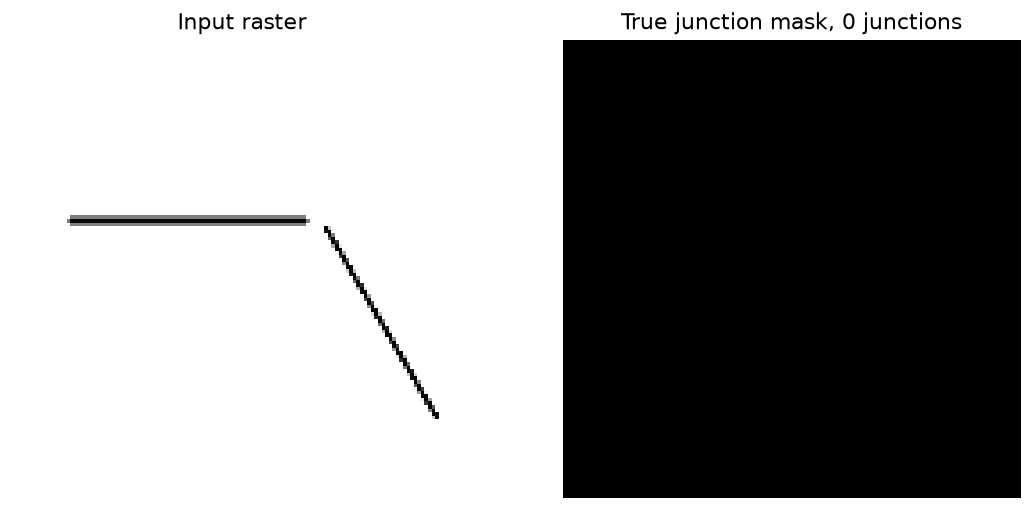

In [4]:
def segment_intersection(a, b, eps=1e-9):
    x1, y1, x2, y2 = map(float, a)
    x3, y3, x4, y4 = map(float, b)
    den = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(den) < eps:
        return None
    px = ((x1*y2 - y1*x2) * (x3 - x4) - (x1 - x2) * (x3*y4 - y3*x4)) / den
    py = ((x1*y2 - y1*x2) * (y3 - y4) - (y1 - y2) * (x3*y4 - y3*x4)) / den

    def between(p, q, r):
        return min(p, r) - 1e-6 <= q <= max(p, r) + 1e-6

    if between(x1, px, x2) and between(y1, py, y2) and between(x3, px, x4) and between(y3, py, y4):
        return px, py
    return None


def junction_mask_from_vectors(vectors, img_size=IMG_SIZE, radius=JUNCTION_RADIUS):
    mask = np.zeros((img_size, img_size), dtype=np.float32)
    points = []
    for i in range(len(vectors)):
        for j in range(i + 1, len(vectors)):
            p = segment_intersection(vectors[i], vectors[j])
            if p is not None:
                points.append(p)
                cx, cy = p
                for y in range(max(0, int(cy - radius)), min(img_size, int(cy + radius) + 1)):
                    for x in range(max(0, int(cx - radius)), min(img_size, int(cx + radius) + 1)):
                        if (x - cx) ** 2 + (y - cy) ** 2 <= radius ** 2:
                            mask[y, x] = 1.0
    return mask, points

train_junction_masks = []
for vecs in train_vectors:
    m, _ = junction_mask_from_vectors(vecs)
    train_junction_masks.append(m)
train_junction_masks = np.stack(train_junction_masks)

sample_idx = 0
jm, pts = junction_mask_from_vectors(train_vectors[sample_idx])
fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=130)
ax[0].imshow(train_images[sample_idx], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[0].set_title('Input raster')
ax[1].imshow(jm, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[1].set_title(f'True junction mask, {len(pts)} junctions')
for a in ax:
    a.axis('off')
plt.show()

## Optional skeletonization utility

The CNN comparison does not require skeletonization globally. This helper only exists so `skeleton` and `close_then_skeleton` can be used as optional preprocessing representations.


In [5]:
def skeletonize_zhang_suen(binary):
    """Pure NumPy Zhang-Suen thinning.

    Input:  1 = stroke, 0 = background
    Output: 1-pixel-wide skeleton, 1 = stroke

    This avoids changing your environment or requiring scikit-image.
    """
    img = (binary > 0).astype(np.uint8).copy()
    h, w = img.shape

    def neighbours(y, x):
        # P2, P3, ..., P9 around P1=(y,x), clockwise from north.
        return [
            img[y - 1, x],     # P2
            img[y - 1, x + 1], # P3
            img[y,     x + 1], # P4
            img[y + 1, x + 1], # P5
            img[y + 1, x],     # P6
            img[y + 1, x - 1], # P7
            img[y,     x - 1], # P8
            img[y - 1, x - 1], # P9
        ]

    changed = True
    while changed:
        changed = False

        for step in (0, 1):
            remove = []

            for y in range(1, h - 1):
                for x in range(1, w - 1):
                    if img[y, x] == 0:
                        continue

                    p = neighbours(y, x)
                    n = sum(p)
                    if n < 2 or n > 6:
                        continue

                    transitions = sum((p[i] == 0 and p[(i + 1) % 8] == 1) for i in range(8))
                    if transitions != 1:
                        continue

                    p2, p3, p4, p5, p6, p7, p8, p9 = p

                    if step == 0:
                        c1 = p2 * p4 * p6 == 0
                        c2 = p4 * p6 * p8 == 0
                    else:
                        c1 = p2 * p4 * p8 == 0
                        c2 = p2 * p6 * p8 == 0

                    if c1 and c2:
                        remove.append((y, x))

            if remove:
                for y, x in remove:
                    img[y, x] = 0
                changed = True

    return img.astype(np.uint8)


## Preprocessing methods to compare

Each preprocessing method converts the same raw raster into a CNN input representation. The CNN is still the only learned detection/regression method.

This section compares:

- **single-channel inputs**, where each CNN receives one preprocessing representation; and
- **one multi-channel input**, where one CNN receives several preprocessing representations stacked together as channels.

The multi-channel model is not extra augmentation. It is one training example per drawing, but each example contains several feature views of the same drawing.


Preprocessing methods prepared:
  preprocess_method            display_name               kind  input_channels                                                                                                           channel_names         train_shape          test_shape  mean_train_raw_stroke_pixels  mean_train_processed_feature_pixels  mean_test_raw_stroke_pixels  mean_test_processed_feature_pixels  opening_radius  closing_radius  erode_radius  dilate_radius  density_radius  distance_decay_px  neighbour_blend  apply_skeletonization
     threshold_only        Threshold binary             binary               1                                                                                                                            (6000, 128, 128)    (1200, 128, 128)                      325.7315                           325.731500                   317.494167                          317.494167               0               0             0              0               0              

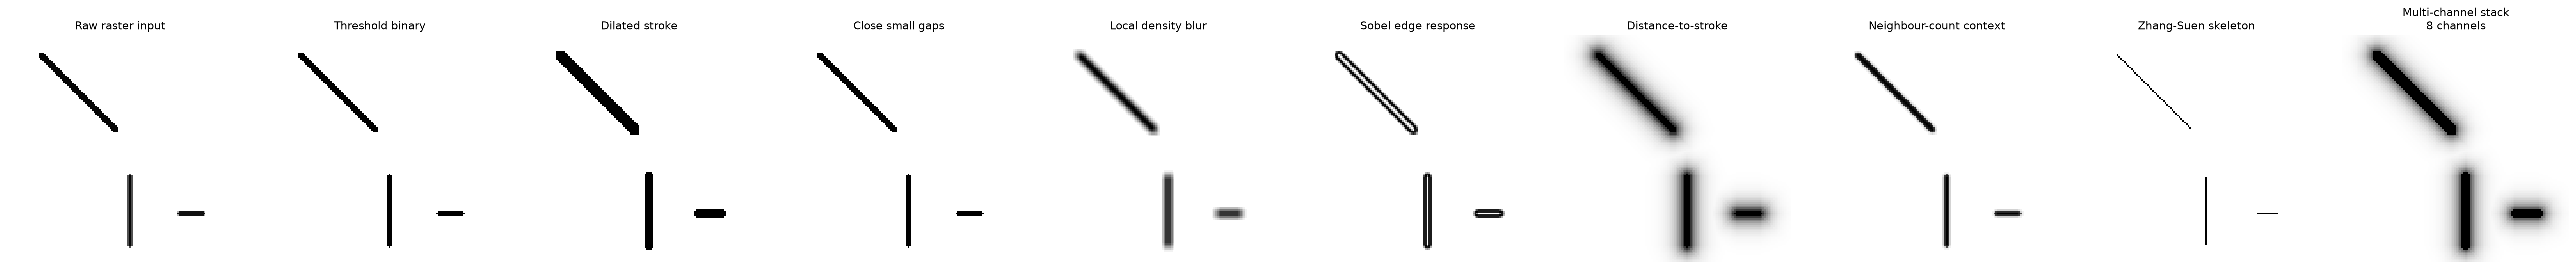

In [6]:
# Preprocessing comparison stage.
import pandas as pd
# No external image-processing packages are required.
# Zhang-Suen skeletonization is only one optional representation.

# ------------------------------------------------------------
# Preprocessing method registry
# ------------------------------------------------------------
# kind controls the final representation given to the CNN.
# Morphology settings are applied before representation construction.
#
# Useful kinds:
# - "binary"            : normal black/white stroke raster
# - "local_density"     : blurred local stroke-density map
# - "sobel_edges"       : Sobel edge-response map
# - "distance_transform": dark near the stroke, lighter with distance
# - "neighbour_context" : neighbour-count/topology response around line pixels
# - "skeleton"          : Zhang-Suen one-pixel skeleton
#
# All outputs keep the notebook convention: 0 = feature/stroke, 1 = background.

PREPROCESS_METHODS = {
    "threshold_only": {
        "display_name": "Threshold binary",
        "kind": "binary",
        "threshold": 0.5,
    },

    # Morphology variants: these are not skeletonisation.
    "dilated_stroke": {
        "display_name": "Dilated stroke",
        "kind": "binary",
        "threshold": 0.5,
        "dilate_radius": 1,
    },
    "eroded_stroke": {
        "display_name": "Eroded stroke",
        "kind": "binary",
        "threshold": 0.5,
        "erode_radius": 1,
    },
    "open_remove_noise": {
        "display_name": "Open: remove specks",
        "kind": "binary",
        "threshold": 0.5,
        "opening_radius": 1,
    },
    "close_gaps": {
        "display_name": "Close small gaps",
        "kind": "binary",
        "threshold": 0.5,
        "closing_radius": 1,
    },
    "open_then_close": {
        "display_name": "Open then close",
        "kind": "binary",
        "threshold": 0.5,
        "opening_radius": 1,
        "closing_radius": 1,
    },

    # Continuous-valued representations for the CNN.
    "local_density": {
        "display_name": "Local density blur",
        "kind": "local_density",
        "threshold": 0.5,
        "density_radius": 2,
    },
    "sobel_edges": {
        "display_name": "Sobel edge response",
        "kind": "sobel_edges",
        "threshold": 0.5,
    },
    "distance_transform": {
        "display_name": "Distance-to-stroke",
        "kind": "distance_transform",
        "threshold": 0.5,
        "distance_decay_px": 4.0,
    },
    "neighbour_context": {
        "display_name": "Neighbour-count context",
        "kind": "neighbour_context",
        "threshold": 0.5,
        "neighbour_blend": 0.45,
    },

    # Skeleton is kept, but it is just one method in the wider comparison.
    "skeleton": {
        "display_name": "Zhang-Suen skeleton",
        "kind": "skeleton",
        "threshold": 0.5,
    },
    "close_then_skeleton": {
        "display_name": "Close gaps + skeleton",
        "kind": "skeleton",
        "threshold": 0.5,
        "closing_radius": 1,
    },
}

# Default active set: deliberately varied but still fast enough for a quick run.
# Add/remove names from PREPROCESS_METHODS here when you want a wider or smaller comparison.
ACTIVE_PREPROCESS_METHODS = [
    "threshold_only",
    "dilated_stroke",
    "close_gaps",
    "local_density",
    "sobel_edges",
    "distance_transform",
    "neighbour_context",
    "skeleton",
]

DEFAULT_PREPROCESS_METHOD = "threshold_only"

# Optional combined-input model.
# The single-channel models above still train as before.
# This extra model sees several preprocessing results of the same drawing as separate CNN channels.
ENABLE_MULTI_CHANNEL_PREPROCESS = True
MULTI_CHANNEL_PREPROCESS_METHOD = "multi_channel_stack"
MULTI_CHANNEL_PREPROCESS_METHODS = [
    "threshold_only",
    "dilated_stroke",
    "close_gaps",
    "local_density",
    "sobel_edges",
    "distance_transform",
    "neighbour_context",
    "skeleton",
]


def stroke_mask_to_raster_image(mask):
    """Convert a binary feature/stroke mask into notebook raster format: black feature on white background."""
    mask = (mask > 0).astype(np.uint8)
    return np.where(mask == 1, 0.0, 1.0).astype(np.float32)


# Backwards-compatible name used by older cells.
skeleton_mask_to_raster_image = stroke_mask_to_raster_image


def ensure_0_1_image(image):
    """Clip a float image into [0, 1] and convert to float32."""
    return np.clip(np.asarray(image, dtype=np.float32), 0.0, 1.0).astype(np.float32)


def binary_dilate_np(mask, radius=1):
    """Small pure-NumPy binary dilation using a square window."""
    radius = int(radius)
    mask = (mask > 0).astype(np.uint8)
    if radius <= 0:
        return mask.copy()

    h, w = mask.shape
    padded = np.pad(mask, radius, mode='constant', constant_values=0)
    out = np.zeros_like(mask, dtype=np.uint8)

    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            out |= padded[
                radius + dy: radius + dy + h,
                radius + dx: radius + dx + w,
            ]
    return out


def binary_erode_np(mask, radius=1):
    """Small pure-NumPy binary erosion using a square window."""
    radius = int(radius)
    mask = (mask > 0).astype(np.uint8)
    if radius <= 0:
        return mask.copy()

    h, w = mask.shape
    padded = np.pad(mask, radius, mode='constant', constant_values=0)
    out = np.ones_like(mask, dtype=np.uint8)

    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            out &= padded[
                radius + dy: radius + dy + h,
                radius + dx: radius + dx + w,
            ]
    return out


def binary_open_np(mask, radius=1):
    """Erosion followed by dilation; useful for removing isolated specks/noise."""
    return binary_dilate_np(binary_erode_np(mask, radius=radius), radius=radius)


def binary_close_np(mask, radius=1):
    """Dilation followed by erosion; useful for closing tiny raster gaps."""
    return binary_erode_np(binary_dilate_np(mask, radius=radius), radius=radius)


def box_blur_np(image, radius=1):
    """Pure-NumPy mean filter. Used to make local-density CNN inputs without scipy/skimage."""
    radius = int(radius)
    image = np.asarray(image, dtype=np.float32)
    if radius <= 0:
        return image.copy()

    h, w = image.shape
    padded = np.pad(image, radius, mode='edge')
    out = np.zeros_like(image, dtype=np.float32)
    count = 0

    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            out += padded[
                radius + dy: radius + dy + h,
                radius + dx: radius + dx + w,
            ]
            count += 1

    return out / max(count, 1)


def conv2d_np(image, kernel):
    """Small 2D convolution helper for fixed kernels."""
    image = np.asarray(image, dtype=np.float32)
    kernel = np.asarray(kernel, dtype=np.float32)
    kh, kw = kernel.shape
    py, px = kh // 2, kw // 2
    padded = np.pad(image, ((py, py), (px, px)), mode='edge')
    out = np.zeros_like(image, dtype=np.float32)

    for y in range(kh):
        for x in range(kw):
            out += kernel[y, x] * padded[y:y + image.shape[0], x:x + image.shape[1]]
    return out


def sobel_magnitude_np(stroke_mask):
    """Sobel magnitude, normalized to 0..1."""
    img = np.asarray(stroke_mask, dtype=np.float32)
    gx = conv2d_np(img, np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1],
    ], dtype=np.float32))
    gy = conv2d_np(img, np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1],
    ], dtype=np.float32))
    mag = np.sqrt(gx * gx + gy * gy)
    max_mag = float(mag.max())
    if max_mag > 0:
        mag = mag / max_mag
    return mag.astype(np.float32)


def chamfer_distance_to_stroke_np(stroke_mask):
    """Approximate distance transform to nearest stroke pixel using a two-pass chamfer update.

    Stroke pixels have distance 0. Background pixels increase with distance from the nearest stroke.
    This avoids needing scipy.ndimage.distance_transform_edt.
    """
    stroke_mask = (stroke_mask > 0).astype(np.uint8)
    h, w = stroke_mask.shape
    inf = 1e6
    dist = np.where(stroke_mask > 0, 0.0, inf).astype(np.float32)

    diag = math.sqrt(2.0)

    for y in range(h):
        for x in range(w):
            best = dist[y, x]
            if y > 0:
                best = min(best, dist[y - 1, x] + 1.0)
                if x > 0:
                    best = min(best, dist[y - 1, x - 1] + diag)
                if x + 1 < w:
                    best = min(best, dist[y - 1, x + 1] + diag)
            if x > 0:
                best = min(best, dist[y, x - 1] + 1.0)
            dist[y, x] = best

    for y in range(h - 1, -1, -1):
        for x in range(w - 1, -1, -1):
            best = dist[y, x]
            if y + 1 < h:
                best = min(best, dist[y + 1, x] + 1.0)
                if x > 0:
                    best = min(best, dist[y + 1, x - 1] + diag)
                if x + 1 < w:
                    best = min(best, dist[y + 1, x + 1] + diag)
            if x + 1 < w:
                best = min(best, dist[y, x + 1] + 1.0)
            dist[y, x] = best

    return dist


def neighbour_count_image_np(mask):
    """For each pixel, count 8-neighbours that are stroke pixels."""
    mask = (mask > 0).astype(np.uint8)
    h, w = mask.shape
    padded = np.pad(mask, 1, mode='constant', constant_values=0)
    out = np.zeros_like(mask, dtype=np.float32)

    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            if dy == 0 and dx == 0:
                continue
            out += padded[1 + dy:1 + dy + h, 1 + dx:1 + dx + w]

    return out


def apply_pre_morphology(raw_stroke, config):
    """Apply optional morphology before constructing the final CNN input representation."""
    stroke = (raw_stroke > 0).astype(np.uint8).copy()

    opening_radius = int(config.get("opening_radius", 0))
    if opening_radius > 0:
        stroke = binary_open_np(stroke, radius=opening_radius)

    closing_radius = int(config.get("closing_radius", 0))
    if closing_radius > 0:
        stroke = binary_close_np(stroke, radius=closing_radius)

    erode_radius = int(config.get("erode_radius", 0))
    if erode_radius > 0:
        stroke = binary_erode_np(stroke, radius=erode_radius)

    dilate_radius = int(config.get("dilate_radius", 0))
    if dilate_radius > 0:
        stroke = binary_dilate_np(stroke, radius=dilate_radius)

    return stroke


def preprocess_raster_image(image, config):
    """Apply one preprocessing configuration to one raster image.

    Input image convention:  0 = black/stroke, 1 = white/background.
    Output image convention: 0 = strong feature/stroke, 1 = background/no feature.
    """
    threshold = float(config.get("threshold", 0.5))
    raw_stroke = (image <= threshold).astype(np.uint8)
    stroke = apply_pre_morphology(raw_stroke, config)

    kind = config.get("kind", "binary")

    if kind == "binary":
        feature_strength = stroke.astype(np.float32)

    elif kind == "skeleton":
        feature_strength = skeletonize_zhang_suen(stroke).astype(np.float32)

    elif kind == "local_density":
        radius = int(config.get("density_radius", 2))
        feature_strength = box_blur_np(stroke.astype(np.float32), radius=radius)
        max_value = float(feature_strength.max())
        if max_value > 0:
            feature_strength = feature_strength / max_value

    elif kind == "sobel_edges":
        feature_strength = sobel_magnitude_np(stroke.astype(np.float32))

    elif kind == "distance_transform":
        decay = float(config.get("distance_decay_px", 4.0))
        dist = chamfer_distance_to_stroke_np(stroke)
        feature_strength = np.exp(-dist / max(decay, 1e-6)).astype(np.float32)

    elif kind == "neighbour_context":
        # Blend line presence with local 8-neighbour count.
        # This gives the CNN a simple topology hint without thinning the drawing.
        blend = float(config.get("neighbour_blend", 0.45))
        neighbours = neighbour_count_image_np(stroke) / 8.0
        feature_strength = (1.0 - blend) * stroke.astype(np.float32) + blend * neighbours
        feature_strength = np.clip(feature_strength, 0.0, 1.0)

    else:
        raise ValueError(f"Unknown preprocessing kind: {kind}")

    # Convert feature strength to notebook image convention.
    # feature_strength: 1 = strong feature, 0 = none
    # processed_image: 0 = strong feature, 1 = none
    processed_image = ensure_0_1_image(1.0 - feature_strength)

    # For summaries/metrics, count pixels that are visibly feature-like after preprocessing.
    processed_feature_mask = (processed_image <= 0.5).astype(np.uint8)

    debug = {
        "kind": kind,
        "raw_stroke": raw_stroke,
        "processed_stroke": processed_feature_mask,
        "raw_stroke_pixels": int(raw_stroke.sum()),
        "processed_stroke_pixels": int(processed_feature_mask.sum()),
        "threshold": threshold,
        "opening_radius": int(config.get("opening_radius", 0)),
        "closing_radius": int(config.get("closing_radius", 0)),
        "erode_radius": int(config.get("erode_radius", 0)),
        "dilate_radius": int(config.get("dilate_radius", 0)),
        "density_radius": int(config.get("density_radius", 0)),
        "distance_decay_px": float(config.get("distance_decay_px", 0.0)),
        "neighbour_blend": float(config.get("neighbour_blend", 0.0)),
        "apply_opening": int(config.get("opening_radius", 0)) > 0,
        "apply_closing": int(config.get("closing_radius", 0)) > 0,
        "apply_erosion": int(config.get("erode_radius", 0)) > 0,
        "apply_dilation": int(config.get("dilate_radius", 0)) > 0,
        "apply_skeletonization": kind == "skeleton",
    }
    return processed_image, debug


def preprocess_raster_dataset(images, config):
    processed_images = []
    debug_rows = []
    for image in images:
        processed_image, debug = preprocess_raster_image(image, config=config)
        processed_images.append(processed_image)
        debug_rows.append(debug)
    return np.stack(processed_images).astype(np.float32), debug_rows


preprocessed_datasets = {}
preprocess_summary_rows = []


def add_preprocess_summary_row(preprocess_name, config, train_images, test_images, train_debug, test_debug):
    """Collect one row describing a prepared preprocessing representation."""
    train_arr = np.asarray(train_images)
    test_arr = np.asarray(test_images)
    channel_names = config.get("channels", [])

    preprocess_summary_rows.append({
        "preprocess_method": preprocess_name,
        "display_name": config.get("display_name", preprocess_name),
        "kind": config.get("kind", "binary"),
        "input_channels": int(train_arr.shape[1]) if train_arr.ndim == 4 else 1,
        "channel_names": ", ".join(channel_names) if channel_names else "",
        "train_shape": str(train_arr.shape),
        "test_shape": str(test_arr.shape),
        "mean_train_raw_stroke_pixels": np.mean([d["raw_stroke_pixels"] for d in train_debug]),
        "mean_train_processed_feature_pixels": np.mean([d["processed_stroke_pixels"] for d in train_debug]),
        "mean_test_raw_stroke_pixels": np.mean([d["raw_stroke_pixels"] for d in test_debug]),
        "mean_test_processed_feature_pixels": np.mean([d["processed_stroke_pixels"] for d in test_debug]),
        "opening_radius": int(config.get("opening_radius", 0)),
        "closing_radius": int(config.get("closing_radius", 0)),
        "erode_radius": int(config.get("erode_radius", 0)),
        "dilate_radius": int(config.get("dilate_radius", 0)),
        "density_radius": int(config.get("density_radius", 0)),
        "distance_decay_px": float(config.get("distance_decay_px", 0.0)),
        "neighbour_blend": float(config.get("neighbour_blend", 0.0)),
        "apply_skeletonization": bool(config.get("kind", "binary") == "skeleton" or config.get("uses_skeleton_channel", False)),
    })


def make_multi_channel_debug_rows(display_images, base_debug_rows, channel_names):
    """Debug rows for a stacked-channel representation.

    The actual CNN input has several channels. For pixel summaries and previews we also keep a
    2D display image made from the darkest/most feature-like value across channels.
    """
    rows = []
    for display_image, base_debug in zip(display_images, base_debug_rows):
        processed_feature_mask = (display_image <= 0.5).astype(np.uint8)
        rows.append({
            "kind": "multi_channel",
            "raw_stroke": base_debug.get("raw_stroke"),
            "processed_stroke": processed_feature_mask,
            "raw_stroke_pixels": int(base_debug.get("raw_stroke_pixels", 0)),
            "processed_stroke_pixels": int(processed_feature_mask.sum()),
            "threshold": float(base_debug.get("threshold", 0.5)),
            "opening_radius": 0,
            "closing_radius": 0,
            "erode_radius": 0,
            "dilate_radius": 0,
            "density_radius": 0,
            "distance_decay_px": 0.0,
            "neighbour_blend": 0.0,
            "apply_opening": False,
            "apply_closing": False,
            "apply_erosion": False,
            "apply_dilation": False,
            "apply_skeletonization": "skeleton" in channel_names or "close_then_skeleton" in channel_names,
            "channel_count": len(channel_names),
            "channel_names": list(channel_names),
        })
    return rows


def get_preprocess_display_image(preprocess_name, split, idx):
    """Return a 2D image for plotting/pixel metrics even when the model input is multi-channel."""
    dataset = preprocessed_datasets[preprocess_name]
    display_key = f"{split}_display_images"
    if display_key in dataset:
        return dataset[display_key][idx]

    image = dataset[f"{split}_images"][idx]
    image = np.asarray(image)
    if image.ndim == 2:
        return image
    if image.ndim == 3:
        # Input convention: channels are 0=feature, 1=background.
        # Use the minimum so a feature in any channel remains visible in previews.
        return np.min(image, axis=0).astype(np.float32)
    raise ValueError(f"Cannot display image with shape {image.shape}")


# 1) Prepare the single-channel preprocessing datasets.
for preprocess_name in ACTIVE_PREPROCESS_METHODS:
    if preprocess_name not in PREPROCESS_METHODS:
        raise KeyError(f"Unknown preprocessing method: {preprocess_name}")

    config = PREPROCESS_METHODS[preprocess_name]
    train_processed, train_debug = preprocess_raster_dataset(train_images, config)
    test_processed, test_debug = preprocess_raster_dataset(test_images, config)

    preprocessed_datasets[preprocess_name] = {
        "config": config,
        "train_images": train_processed,
        "test_images": test_processed,
        "train_debug": train_debug,
        "test_debug": test_debug,
    }

    add_preprocess_summary_row(
        preprocess_name,
        config,
        train_processed,
        test_processed,
        train_debug,
        test_debug,
    )


# 2) Prepare one stacked multi-channel dataset.
if ENABLE_MULTI_CHANNEL_PREPROCESS:
    missing = [name for name in MULTI_CHANNEL_PREPROCESS_METHODS if name not in preprocessed_datasets]
    if missing:
        raise KeyError(
            "The multi-channel stack can only use methods already prepared in ACTIVE_PREPROCESS_METHODS. "
            f"Missing: {missing}"
        )

    train_stack = np.stack(
        [preprocessed_datasets[name]["train_images"] for name in MULTI_CHANNEL_PREPROCESS_METHODS],
        axis=1,
    ).astype(np.float32)

    test_stack = np.stack(
        [preprocessed_datasets[name]["test_images"] for name in MULTI_CHANNEL_PREPROCESS_METHODS],
        axis=1,
    ).astype(np.float32)

    # 2D preview/metric target for the multi-channel input.
    # It is not the model input; it is only a visual summary of the stacked channels.
    train_display = np.min(train_stack, axis=1).astype(np.float32)
    test_display = np.min(test_stack, axis=1).astype(np.float32)

    multi_config = {
        "display_name": "Multi-channel stack",
        "kind": "multi_channel",
        "channels": list(MULTI_CHANNEL_PREPROCESS_METHODS),
        "uses_skeleton_channel": "skeleton" in MULTI_CHANNEL_PREPROCESS_METHODS or "close_then_skeleton" in MULTI_CHANNEL_PREPROCESS_METHODS,
    }
    PREPROCESS_METHODS[MULTI_CHANNEL_PREPROCESS_METHOD] = multi_config

    base_debug_train = preprocessed_datasets[DEFAULT_PREPROCESS_METHOD]["train_debug"]
    base_debug_test = preprocessed_datasets[DEFAULT_PREPROCESS_METHOD]["test_debug"]
    train_debug = make_multi_channel_debug_rows(train_display, base_debug_train, MULTI_CHANNEL_PREPROCESS_METHODS)
    test_debug = make_multi_channel_debug_rows(test_display, base_debug_test, MULTI_CHANNEL_PREPROCESS_METHODS)

    preprocessed_datasets[MULTI_CHANNEL_PREPROCESS_METHOD] = {
        "config": multi_config,
        "train_images": train_stack,
        "test_images": test_stack,
        "train_display_images": train_display,
        "test_display_images": test_display,
        "train_debug": train_debug,
        "test_debug": test_debug,
    }

    add_preprocess_summary_row(
        MULTI_CHANNEL_PREPROCESS_METHOD,
        multi_config,
        train_stack,
        test_stack,
        train_debug,
        test_debug,
    )


TRAIN_PREPROCESS_METHODS = list(ACTIVE_PREPROCESS_METHODS)
if ENABLE_MULTI_CHANNEL_PREPROCESS:
    TRAIN_PREPROCESS_METHODS.append(MULTI_CHANNEL_PREPROCESS_METHOD)

preprocess_summary_df = pd.DataFrame(preprocess_summary_rows)

# Backward-compatible aliases for older preview/debug cells.
train_images_preprocessed = preprocessed_datasets[DEFAULT_PREPROCESS_METHOD]["train_images"]
test_images_preprocessed = preprocessed_datasets[DEFAULT_PREPROCESS_METHOD]["test_images"]
train_preprocess_debug = preprocessed_datasets[DEFAULT_PREPROCESS_METHOD]["train_debug"]
test_preprocess_debug = preprocessed_datasets[DEFAULT_PREPROCESS_METHOD]["test_debug"]

print('Preprocessing methods prepared:')
print(preprocess_summary_df.to_string(index=False))
print('\nMethods that will train CNNs:')
print(TRAIN_PREPROCESS_METHODS)

preview_methods = list(TRAIN_PREPROCESS_METHODS)
fig, ax = plt.subplots(1, 1 + len(preview_methods), figsize=(4 * (1 + len(preview_methods)), 4), dpi=130)
ax = np.atleast_1d(ax)
ax[0].imshow(test_images[0], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[0].set_title('Raw raster input')
ax[0].axis('off')

for col, preprocess_name in enumerate(preview_methods, start=1):
    method_info = preprocessed_datasets[preprocess_name]
    preview_image = get_preprocess_display_image(preprocess_name, 'test', 0)
    title = method_info["config"].get("display_name", preprocess_name)
    if method_info["config"].get("kind") == "multi_channel":
        title += f"\n{len(method_info['config'].get('channels', []))} channels"
    ax[col].imshow(preview_image, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    ax[col].set_title(title)
    ax[col].axis('off')

plt.tight_layout()
plt.show()

## Direct learned raster-to-vector model: CNN only

This model is **not a junction classifier**. It learns a direct mapping from raster-derived input channels to a fixed set of line vectors.

Input can be either:

- one preprocessed raster representation with shape `[1, H, W]`; or
- a stacked multi-channel representation with shape `[C, H, W]`.

Label: original synthetic vector list encoded as fixed slots: `[confidence, x0, y0, x1, y1]`.

The CNN architecture is the same idea in both cases; only the number of input channels in the first convolution changes.


In [7]:
# Direct learned raster-to-vector method: CNN only
# ------------------------------------------------
# The CNN uses preprocessed raster channels as input and the true vector list as supervised labels.
# Each model predicts MAX_VECTORS line slots:
#   [confidence, x0, y0, x1, y1]
# The coordinate loss is only applied to slots that contain a true vector.
# Direction is ignored: A->B and B->A are treated as the same line.

import pandas as pd

DIRECT_VECTOR_MODEL_CONFIG = {
    "batch_size": BATCH_SIZE,
    "cnn_epochs": CNN_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": 1e-4,
    "coord_loss_weight": 10.0,
    "no_object_conf_weight": 0.25,
    "confidence_threshold": 0.50,

    # Trains one CNN for each single preprocessing method, plus the multi-channel stack if enabled.
    # Each CNN sees the same input representation during train and test.
    "preprocess_methods_to_train": TRAIN_PREPROCESS_METHODS,
}


def canonicalise_vector_for_learning(vector):
    """Use a stable endpoint order so the network is not asked to learn arbitrary reversals."""
    x0, y0, x1, y1 = map(float, vector[:4])
    if (x1, y1) < (x0, y0):
        x0, y0, x1, y1 = x1, y1, x0, y0
    return (x0, y0, x1, y1)


def sorted_vectors_for_learning(vectors):
    """Sort unordered vector labels into repeatable slots.

    This keeps supervised learning simple. It is still a limitation: line-vector prediction is
    naturally unordered, while this fixed-slot approach imposes an order.
    """
    canon = [canonicalise_vector_for_learning(v) for v in vectors]

    def key(v):
        x0, y0, x1, y1 = v
        cx = 0.5 * (x0 + x1)
        cy = 0.5 * (y0 + y1)
        length = math.hypot(x1 - x0, y1 - y0)
        angle = math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180
        return (round(cy, 3), round(cx, 3), round(angle, 3), round(length, 3))

    return sorted(canon, key=key)


def encode_vector_targets(vector_lists, max_vectors=MAX_VECTORS, img_size=IMG_SIZE):
    """Encode variable-length vector lists into fixed supervised-learning tensors."""
    n = len(vector_lists)
    target_conf = np.zeros((n, max_vectors), dtype=np.float32)
    target_coords = np.zeros((n, max_vectors, 4), dtype=np.float32)
    scale = float(img_size - 1)

    for i, vectors in enumerate(vector_lists):
        vectors = sorted_vectors_for_learning(vectors)[:max_vectors]
        for j, vector in enumerate(vectors):
            target_conf[i, j] = 1.0
            target_coords[i, j] = np.asarray(vector, dtype=np.float32) / scale

    return target_conf, target_coords


def make_direct_vector_tensors(images, vector_lists):
    """Create PyTorch tensors for direct vector regression.

    Accepted image shapes:
    - single-channel batch: [N, H, W]
    - multi-channel batch:  [N, C, H, W]

    The notebook image convention is 0=stroke/feature and 1=background.
    The model input uses 1=stroke/feature and 0=background.
    """
    images = np.asarray(images, dtype=np.float32)
    x = 1.0 - images

    if x.ndim == 3:
        x = x[:, None, :, :]
    elif x.ndim == 4:
        pass
    else:
        raise ValueError(f"Expected images with shape [N,H,W] or [N,C,H,W], got {images.shape}")

    x = torch.from_numpy(x.astype(np.float32))

    target_conf, target_coords = encode_vector_targets(vector_lists)
    y_conf = torch.from_numpy(target_conf)
    y_coords = torch.from_numpy(target_coords)
    return x, y_conf, y_coords


class DirectLineCNN(nn.Module):
    """Convolutional direct vector regressor: raster-channel structure -> vector slots."""
    def __init__(self, max_vectors=MAX_VECTORS, input_channels=1):
        super().__init__()
        self.max_vectors = max_vectors
        self.input_channels = int(input_channels)
        self.features = nn.Sequential(
            nn.Conv2d(self.input_channels, 16, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.10),
            nn.Linear(512, max_vectors * 5),
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x).view(x.shape[0], self.max_vectors, 5)


def direction_invariant_coord_loss(coord_pred, target_coords):
    """
    Coordinate loss where line direction does not matter.

    A predicted segment is compared against:
    1. target:          x0, y0, x1, y1
    2. reversed target: x1, y1, x0, y0

    The smaller loss is used.
    """
    target_reversed = target_coords[..., [2, 3, 0, 1]]

    loss_forward = F.smooth_l1_loss(
        coord_pred,
        target_coords,
        reduction='none',
    ).mean(dim=-1)

    loss_reversed = F.smooth_l1_loss(
        coord_pred,
        target_reversed,
        reduction='none',
    ).mean(dim=-1)

    return torch.minimum(loss_forward, loss_reversed).mean()


def direct_vector_loss(pred, target_conf, target_coords, config=DIRECT_VECTOR_MODEL_CONFIG):
    """BCE objectness + direction-invariant coordinate regression."""
    conf_logits = pred[..., 0]
    coord_pred = torch.sigmoid(pred[..., 1:])

    bce_raw = F.binary_cross_entropy_with_logits(
        conf_logits,
        target_conf,
        reduction='none',
    )

    noobj_weight = float(config["no_object_conf_weight"])

    bce_weights = torch.where(
        target_conf > 0.5,
        torch.ones_like(target_conf),
        torch.full_like(target_conf, noobj_weight),
    )

    conf_loss = (bce_raw * bce_weights).mean()

    positive_slots = target_conf > 0.5

    if positive_slots.any():
        coord_loss = direction_invariant_coord_loss(
            coord_pred[positive_slots],
            target_coords[positive_slots],
        )
    else:
        coord_loss = torch.zeros((), device=pred.device)

    total_loss = conf_loss + float(config["coord_loss_weight"]) * coord_loss

    return total_loss, conf_loss.detach(), coord_loss.detach()


def train_direct_vector_cnn(model_name, images, vector_lists, config=DIRECT_VECTOR_MODEL_CONFIG):
    x, y_conf, y_coords = make_direct_vector_tensors(images, vector_lists)
    dataset = TensorDataset(x, y_conf, y_coords)
    loader = DataLoader(
        dataset,
        batch_size=int(config["batch_size"]),
        shuffle=True,
        drop_last=False,
    )

    input_channels = int(x.shape[1])
    model = DirectLineCNN(input_channels=input_channels).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(config["learning_rate"]),
        weight_decay=float(config["weight_decay"]),
    )

    epochs = int(config["cnn_epochs"])
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        total_conf = 0.0
        total_coord = 0.0
        n_batches = 0

        for xb, confb, coordsb in loader:
            xb = xb.to(DEVICE)
            confb = confb.to(DEVICE)
            coordsb = coordsb.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss, conf_loss, coord_loss = direct_vector_loss(pred, confb, coordsb, config)
            loss.backward()
            optimizer.step()

            total += float(loss.item())
            total_conf += float(conf_loss.item())
            total_coord += float(coord_loss.item())
            n_batches += 1

        row = {
            "model": model_name,
            "input_channels": input_channels,
            "epoch": epoch,
            "loss": total / max(n_batches, 1),
            "conf_loss": total_conf / max(n_batches, 1),
            "coord_loss": total_coord / max(n_batches, 1),
        }
        history.append(row)
        print(
            f'{model_name} epoch {epoch:02d}/{epochs}: '
            f'loss={row["loss"]:.4f}, '
            f'conf={row["conf_loss"]:.4f}, '
            f'coord={row["coord_loss"]:.4f}'
        )

    return model.eval(), pd.DataFrame(history)


def decode_direct_vector_prediction(
    pred,
    confidence_threshold=None,
    img_size=IMG_SIZE,
    min_length=MIN_VECTOR_LENGTH,
):
    """Decode one model prediction tensor into a list of line vectors."""
    if confidence_threshold is None:
        confidence_threshold = float(DIRECT_VECTOR_MODEL_CONFIG["confidence_threshold"])

    with torch.no_grad():
        conf = torch.sigmoid(pred[..., 0]).detach().cpu().numpy()
        coords = torch.sigmoid(pred[..., 1:]).detach().cpu().numpy()

    vectors = []
    confidences = []
    scale = float(img_size - 1)

    for slot_idx in np.argsort(-conf):
        score = float(conf[slot_idx])
        if score < confidence_threshold:
            continue

        x0, y0, x1, y1 = coords[slot_idx] * scale
        x0, y0 = clip_point(x0, y0, img_size)
        x1, y1 = clip_point(x1, y1, img_size)

        if math.hypot(x1 - x0, y1 - y0) < min_length:
            continue

        vector = tuple(map(int, canonicalise_vector_for_learning((x0, y0, x1, y1))))
        if vector not in vectors:
            vectors.append(vector)
            confidences.append(score)

    return vectors, confidences


def make_model_input_tensor_from_preprocessed_image(image):
    """Convert one preprocessed image or channel stack into a model input tensor."""
    image = np.asarray(image, dtype=np.float32)
    x = 1.0 - image

    if x.ndim == 2:
        x = x[None, None, :, :]
    elif x.ndim == 3:
        x = x[None, :, :, :]
    else:
        raise ValueError(f"Expected one image with shape [H,W] or [C,H,W], got {image.shape}")

    return torch.from_numpy(x.astype(np.float32)).to(DEVICE)


def predict_direct_vectors_from_image(model, image, model_name, preprocess_method=None):
    """Comparison-method wrapper: one preprocessed input -> predicted vectors + debug dict."""
    model.eval()
    x = make_model_input_tensor_from_preprocessed_image(image)
    with torch.no_grad():
        pred = model(x)[0]

    vectors, confidences = decode_direct_vector_prediction(pred)
    debug = {
        "model_type": model_name,
        "preprocess_method": preprocess_method,
        "confidence_threshold": DIRECT_VECTOR_MODEL_CONFIG["confidence_threshold"],
        "slot_confidences_above_threshold": confidences,
        "nodes": [],
        "paths": [],
        "classification_counts": {},
        "input_shape": tuple(np.asarray(image).shape),
        "input_channels": int(np.asarray(image).shape[0]) if np.asarray(image).ndim == 3 else 1,
        "internal_skeletonization_applied": False,
    }
    return vectors, debug


print('CNN-only direct vector training config:')
print(pd.DataFrame([DIRECT_VECTOR_MODEL_CONFIG]).to_string(index=False))

DIRECT_VECTOR_TRAINING_HISTORY = []
direct_cnn_models_by_preprocess = {}

for preprocess_name in DIRECT_VECTOR_MODEL_CONFIG["preprocess_methods_to_train"]:
    if preprocess_name not in preprocessed_datasets:
        raise KeyError(f"Preprocessing method has not been prepared: {preprocess_name}")

    train_input_images = preprocessed_datasets[preprocess_name]["train_images"]
    model_name = f"cnn_direct_vector_regression__{preprocess_name}"

    print(f"\nTraining {model_name}")
    direct_cnn_models_by_preprocess[preprocess_name], history_df = train_direct_vector_cnn(
        model_name,
        train_input_images,
        train_vectors,
    )
    history_df["preprocess_method"] = preprocess_name
    history_df["preprocess_display"] = PREPROCESS_METHODS[preprocess_name].get("display_name", preprocess_name)
    history_df["preprocess_kind"] = PREPROCESS_METHODS[preprocess_name].get("kind", "unknown")
    DIRECT_VECTOR_TRAINING_HISTORY.append(history_df)

if DIRECT_VECTOR_TRAINING_HISTORY:
    direct_vector_training_history_df = pd.concat(DIRECT_VECTOR_TRAINING_HISTORY, ignore_index=True)
    print('\nTraining history tail:')
    print(direct_vector_training_history_df.tail(10).to_string(index=False))
    display(direct_vector_training_history_df)
else:
    direct_vector_training_history_df = pd.DataFrame()
    print('No CNN models were trained. Check DIRECT_VECTOR_MODEL_CONFIG["preprocess_methods_to_train"].')

# Backward-compatible alias for cells that expect a single direct_cnn_model.
direct_cnn_model = direct_cnn_models_by_preprocess.get(DEFAULT_PREPROCESS_METHOD, None)

CNN-only direct vector training config:
 batch_size  cnn_epochs  learning_rate  weight_decay  coord_loss_weight  no_object_conf_weight  confidence_threshold                                                                                                                    preprocess_methods_to_train
        128          10         0.0003        0.0001               10.0                   0.25                   0.5 [threshold_only, dilated_stroke, close_gaps, local_density, sobel_edges, distance_transform, neighbour_context, skeleton, multi_channel_stack]

Training cnn_direct_vector_regression__threshold_only
cnn_direct_vector_regression__threshold_only epoch 01/10: loss=0.3530, conf=0.1415, coord=0.0212
cnn_direct_vector_regression__threshold_only epoch 02/10: loss=0.2470, conf=0.0952, coord=0.0152
cnn_direct_vector_regression__threshold_only epoch 03/10: loss=0.2053, conf=0.0816, coord=0.0124
cnn_direct_vector_regression__threshold_only epoch 04/10: loss=0.1734, conf=0.0694, coord=0.01

,model,input_channels,epoch,loss,conf_loss,coord_loss,preprocess_method,preprocess_display,preprocess_kind
0,cnn_direct_vector_regression__threshold_only,1,1,0.353012,0.141486,0.021153,threshold_only,Threshold binary,binary
1,cnn_direct_vector_regression__threshold_only,1,2,0.247040,0.095151,0.015189,threshold_only,Threshold binary,binary
2,cnn_direct_vector_regression__threshold_only,1,3,0.205328,0.081648,0.012368,threshold_only,Threshold binary,binary
3,cnn_direct_vector_regression__threshold_only,1,4,0.173392,0.069381,0.010401,threshold_only,Threshold binary,binary
4,cnn_direct_vector_regression__threshold_only,1,5,0.142151,0.056528,0.008562,threshold_only,Threshold binary,binary
...,...,...,...,...,...,...,...,...,...
85,cnn_direct_vector_regression__multi_channel_stack,8,6,0.124317,0.045236,0.007908,multi_channel_stack,Multi-channel stack,multi_channel
86,cnn_direct_vector_regression__multi_channel_stack,8,7,0.102679,0.036043,0.006664,multi_channel_stack,Multi-channel stack,multi_channel
87,cnn_direct_vector_regression__multi_channel_stack,8,8,0.086097,0.029085,0.005701,multi_channel_stack,Multi-channel stack,multi_channel
88,cnn_direct_vector_regression__multi_channel_stack,8,9,0.075529,0.025667,0.004986,multi_channel_stack,Multi-channel stack,multi_channel


# Plot how each CNN learnt

,model,input_channels,epoch,loss,conf_loss,coord_loss,preprocess_method,preprocess_display,preprocess_kind
80,cnn_direct_vector_regression__multi_channel_stack,8,1,0.340693,0.130294,0.021040,multi_channel_stack,Multi-channel stack,multi_channel
81,cnn_direct_vector_regression__multi_channel_stack,8,2,0.243094,0.086160,0.015693,multi_channel_stack,Multi-channel stack,multi_channel
82,cnn_direct_vector_regression__multi_channel_stack,8,3,0.207668,0.075784,0.013188,multi_channel_stack,Multi-channel stack,multi_channel
83,cnn_direct_vector_regression__multi_channel_stack,8,4,0.176361,0.065204,0.011116,multi_channel_stack,Multi-channel stack,multi_channel
84,cnn_direct_vector_regression__multi_channel_stack,8,5,0.146868,0.053139,0.009373,multi_channel_stack,Multi-channel stack,multi_channel
85,cnn_direct_vector_regression__multi_channel_stack,8,6,0.124317,0.045236,0.007908,multi_channel_stack,Multi-channel stack,multi_channel
86,cnn_direct_vector_regression__multi_channel_stack,8,7,0.102679,0.036043,0.006664,multi_channel_stack,Multi-channel stack,multi_channel
87,cnn_direct_vector_regression__multi_channel_stack,8,8,0.086097,0.029085,0.005701,multi_channel_stack,Multi-channel stack,multi_channel
88,cnn_direct_vector_regression__multi_channel_stack,8,9,0.075529,0.025667,0.004986,multi_channel_stack,Multi-channel stack,multi_channel
89,cnn_direct_vector_regression__multi_channel_stack,8,10,0.066859,0.021796,0.004506,multi_channel_stack,Multi-channel stack,multi_channel


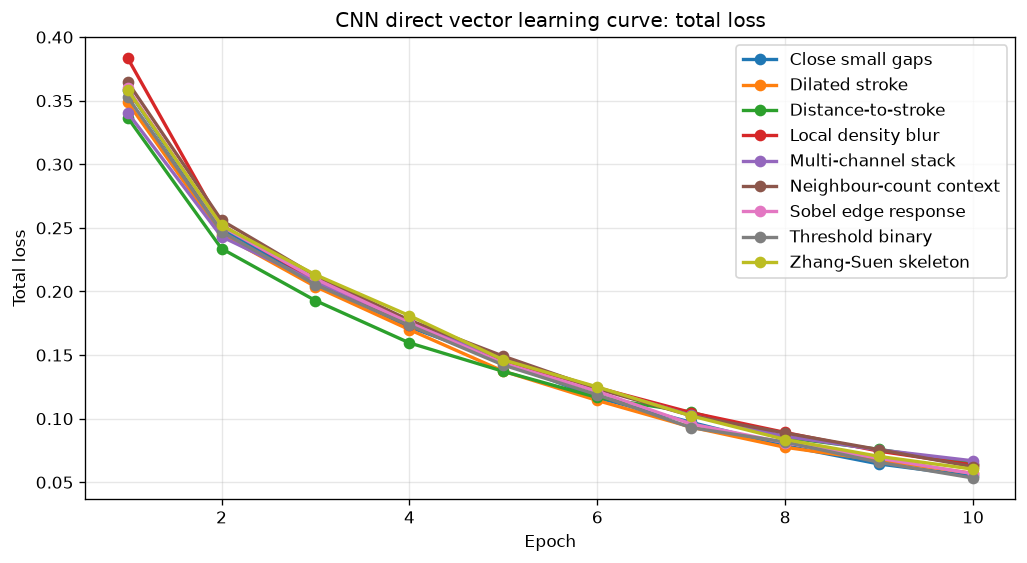

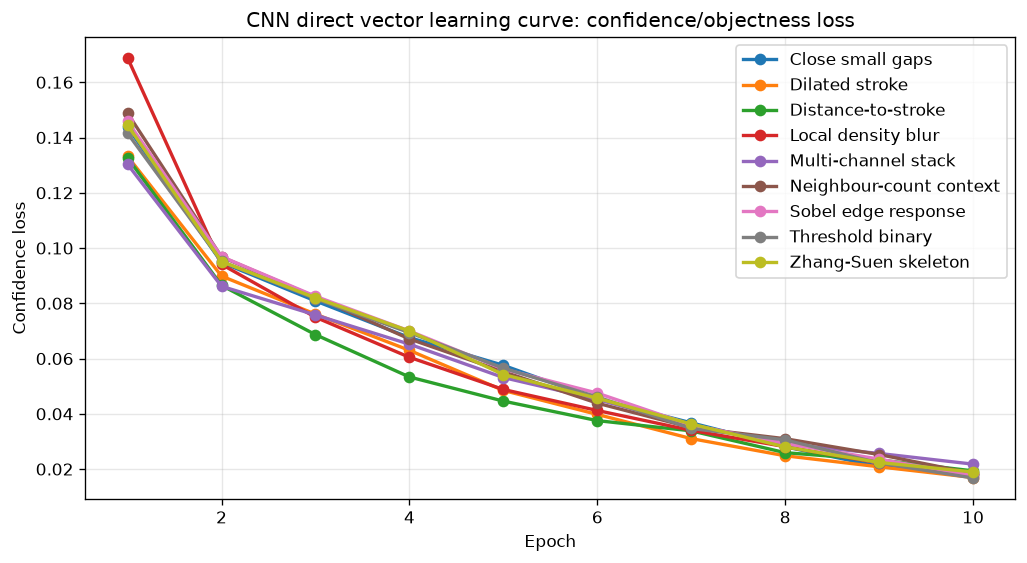

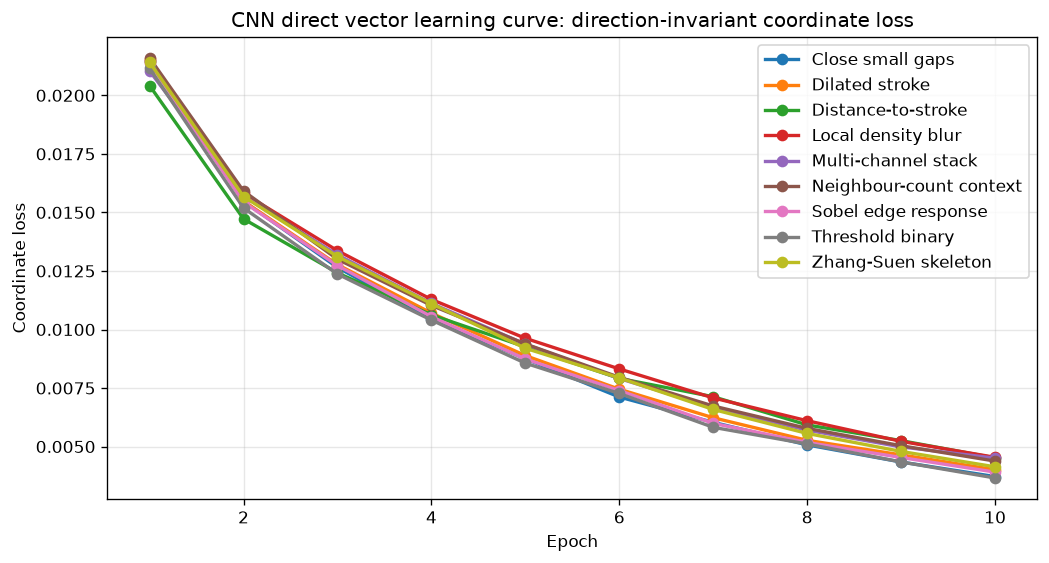

Final CNN training loss by preprocessing method:
  preprocess_method     loss  conf_loss  coord_loss
     threshold_only 0.053365   0.016781    0.003658
         close_gaps 0.054959   0.017770    0.003719
        sobel_edges 0.056766   0.017676    0.003909
     dilated_stroke 0.057071   0.016957    0.004011
           skeleton 0.060308   0.018954    0.004135
  neighbour_context 0.062243   0.018437    0.004381
      local_density 0.063587   0.018170    0.004542
 distance_transform 0.064522   0.019361    0.004516
multi_channel_stack 0.066859   0.021796    0.004506


,model,input_channels,epoch,loss,conf_loss,coord_loss,preprocess_method,preprocess_display,preprocess_kind
9,cnn_direct_vector_regression__threshold_only,1,10,0.053365,0.016781,0.003658,threshold_only,Threshold binary,binary
29,cnn_direct_vector_regression__close_gaps,1,10,0.054959,0.017770,0.003719,close_gaps,Close small gaps,binary
49,cnn_direct_vector_regression__sobel_edges,1,10,0.056766,0.017676,0.003909,sobel_edges,Sobel edge response,sobel_edges
19,cnn_direct_vector_regression__dilated_stroke,1,10,0.057071,0.016957,0.004011,dilated_stroke,Dilated stroke,binary
79,cnn_direct_vector_regression__skeleton,1,10,0.060308,0.018954,0.004135,skeleton,Zhang-Suen skeleton,skeleton
69,cnn_direct_vector_regression__neighbour_context,1,10,0.062243,0.018437,0.004381,neighbour_context,Neighbour-count context,neighbour_context
39,cnn_direct_vector_regression__local_density,1,10,0.063587,0.018170,0.004542,local_density,Local density blur,local_density
59,cnn_direct_vector_regression__distance_transform,1,10,0.064522,0.019361,0.004516,distance_transform,Distance-to-stroke,distance_transform
89,cnn_direct_vector_regression__multi_channel_stack,8,10,0.066859,0.021796,0.004506,multi_channel_stack,Multi-channel stack,multi_channel


In [8]:
if "direct_vector_training_history_df" not in globals():
    raise NameError(
        "direct_vector_training_history_df was not found. "
        "Run the CNN training cell first."
    )

history_df = direct_vector_training_history_df.copy()

if history_df.empty:
    raise ValueError("direct_vector_training_history_df is empty. No training history to plot.")

if "preprocess_display" not in history_df.columns:
    history_df["preprocess_display"] = history_df.get("preprocess_method", history_df["model"])

display(history_df.tail(10))

# ------------------------------------------------------------
# 1. Total loss over epochs
# ------------------------------------------------------------

plt.figure(figsize=(10, 5), dpi=120)

for label, group in history_df.groupby("preprocess_display"):
    plt.plot(
        group["epoch"],
        group["loss"],
        marker="o",
        linewidth=2,
        label=label,
    )

plt.title("CNN direct vector learning curve: total loss")
plt.xlabel("Epoch")
plt.ylabel("Total loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ------------------------------------------------------------
# 2. Confidence loss over epochs
# ------------------------------------------------------------

plt.figure(figsize=(10, 5), dpi=120)

for label, group in history_df.groupby("preprocess_display"):
    plt.plot(
        group["epoch"],
        group["conf_loss"],
        marker="o",
        linewidth=2,
        label=label,
    )

plt.title("CNN direct vector learning curve: confidence/objectness loss")
plt.xlabel("Epoch")
plt.ylabel("Confidence loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ------------------------------------------------------------
# 3. Coordinate loss over epochs
# ------------------------------------------------------------

plt.figure(figsize=(10, 5), dpi=120)

for label, group in history_df.groupby("preprocess_display"):
    plt.plot(
        group["epoch"],
        group["coord_loss"],
        marker="o",
        linewidth=2,
        label=label,
    )

plt.title("CNN direct vector learning curve: direction-invariant coordinate loss")
plt.xlabel("Epoch")
plt.ylabel("Coordinate loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ------------------------------------------------------------
# Final epoch summary
# ------------------------------------------------------------

final_epoch_summary = (
    history_df
    .sort_values(["preprocess_method", "epoch"])
    .groupby("preprocess_method")
    .tail(1)
    .sort_values("loss")
)

print('Final CNN training loss by preprocessing method:')
print(final_epoch_summary[["preprocess_method", "loss", "conf_loss", "coord_loss"]].to_string(index=False))
display(final_epoch_summary)

## Original engineering metrics, reused

In [9]:
import pandas as pd
import numpy as np

METHODS = ["cnn"]


def raster_metrics(true_raster, pred_raster):
    """Pixel-overlap metrics are kept as a secondary check only."""
    true = true_raster < 0.5
    pred = pred_raster < 0.5

    tp = np.logical_and(true, pred).sum()
    fp = np.logical_and(~true, pred).sum()
    fn = np.logical_and(true, ~pred).sum()
    tn = np.logical_and(~true, ~pred).sum()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-9)

    return precision, recall, f1, iou, accuracy


def vector_length_px(v):
    x0, y0, x1, y1 = v
    return math.hypot(x1 - x0, y1 - y0)


def vector_angle_deg(v, config=GEOMETRY_CONFIG):
    """Return an undirected snapped angle in degrees: 0 and 180 are equivalent."""
    x0, y0, x1, y1 = v
    angle = math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180
    return snap_angle_deg(angle, config["angle_unit_deg"])


def angle_distance_deg(a, b):
    """Smallest distance between two undirected line angles."""
    d = abs(a - b) % 180
    return min(d, 180 - d)


def angle_family_importance(angle_deg, config=GEOMETRY_CONFIG):
    """Return a programmable importance weight for an angle.

    Example: 90-degree family angles are more important than arbitrary 1-degree angles.
    This does not change the geometry; it changes how strongly the metric cares about mistakes.
    """
    best = min(config["angle_unit_weights"].values())
    for unit, weight in config["angle_unit_weights"].items():
        if unit <= 1:
            continue
        nearest = round(angle_deg / unit) * unit
        err = angle_distance_deg(angle_deg, nearest)
        if err <= config["angle_unit_deg"] / 2 + 1e-9:
            best = max(best, weight)
    return best


def vector_count_score(true_vectors, pred_vectors):
    denom = max(len(true_vectors), len(pred_vectors), 1)
    return max(0.0, 1.0 - abs(len(true_vectors) - len(pred_vectors)) / denom)


def total_length_score(true_vectors, pred_vectors):
    true_total = sum(snap_length_px(vector_length_px(v)) for v in true_vectors)
    pred_total = sum(snap_length_px(vector_length_px(v)) for v in pred_vectors)
    denom = max(true_total, pred_total, 1e-9)
    return max(0.0, 1.0 - abs(true_total - pred_total) / denom)


def greedy_line_geometry_score(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    """Compare lines by length and angle, not by absolute endpoint location.

    This is the key metric for your goal: a 10x10 square translated slightly should still score well
    because its line lengths and line angles are right.
    """
    if len(true_vectors) == 0 and len(pred_vectors) == 0:
        return 1.0
    if len(true_vectors) == 0 or len(pred_vectors) == 0:
        return 0.0

    candidates = []
    for i, gt in enumerate(true_vectors):
        gt_len = snap_length_px(vector_length_px(gt), config["length_unit_px"])
        gt_ang = vector_angle_deg(gt, config)
        importance = angle_family_importance(gt_ang, config)

        for j, pred in enumerate(pred_vectors):
            pred_len = snap_length_px(vector_length_px(pred), config["length_unit_px"])
            pred_ang = vector_angle_deg(pred, config)

            angle_err = angle_distance_deg(gt_ang, pred_ang)
            length_err = abs(gt_len - pred_len)

            angle_part = max(0.0, 1.0 - angle_err / config["line_angle_tolerance_deg"])
            length_tol = max(config["length_unit_px"], config["length_tolerance_ratio"] * max(gt_len, 1.0))
            length_part = max(0.0, 1.0 - length_err / length_tol)

            pair_score = 0.65 * angle_part + 0.35 * length_part
            candidates.append((pair_score, importance, i, j))

    candidates.sort(reverse=True, key=lambda x: x[0])
    used_true = set()
    used_pred = set()
    weighted_score = 0.0

    for pair_score, importance, i, j in candidates:
        if i in used_true or j in used_pred:
            continue
        used_true.add(i)
        used_pred.add(j)
        weighted_score += pair_score * importance

    total_importance = sum(angle_family_importance(vector_angle_deg(v, config), config) for v in true_vectors)
    return weighted_score / max(total_importance, 1e-9)


def junction_angles_deg(vectors, config=GEOMETRY_CONFIG):
    """Return the acute angles at all places where two predicted/true segments meet or cross.

    This ignores the absolute location of the junction. It cares that the drawing contains the right
    kind of junctions, such as 90-degree corners in a square.
    """
    angles = []
    for i in range(len(vectors)):
        for j in range(i + 1, len(vectors)):
            p = segment_intersection(vectors[i], vectors[j])
            if p is None:
                continue
            a = vector_angle_deg(vectors[i], config)
            b = vector_angle_deg(vectors[j], config)
            d = angle_distance_deg(a, b)
            acute = min(d, 180 - d)
            if acute > 1e-6:
                angles.append(snap_angle_deg(acute, config["angle_unit_deg"]))
    return angles


def angle_list_score(true_angles, pred_angles, tolerance_deg):
    if len(true_angles) == 0 and len(pred_angles) == 0:
        return 1.0
    if len(true_angles) == 0 or len(pred_angles) == 0:
        return 0.0

    candidates = []
    for i, a in enumerate(true_angles):
        for j, b in enumerate(pred_angles):
            err = abs(a - b)
            score = max(0.0, 1.0 - err / tolerance_deg)
            candidates.append((score, i, j))

    candidates.sort(reverse=True, key=lambda x: x[0])
    used_true = set()
    used_pred = set()
    total = 0.0

    for score, i, j in candidates:
        if i in used_true or j in used_pred:
            continue
        used_true.add(i)
        used_pred.add(j)
        total += score

    return total / max(len(true_angles), len(pred_angles), 1)


def engineering_metrics(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    line_geometry = greedy_line_geometry_score(true_vectors, pred_vectors, config)
    length_total = total_length_score(true_vectors, pred_vectors)
    count = vector_count_score(true_vectors, pred_vectors)

    true_junction_angles = junction_angles_deg(true_vectors, config)
    pred_junction_angles = junction_angles_deg(pred_vectors, config)
    junction_angles = angle_list_score(
        true_junction_angles,
        pred_junction_angles,
        config["junction_angle_tolerance_deg"],
    )

    w = config["score_weights"]
    engineering_score = (
        w["line_geometry"] * line_geometry
        + w["total_length"] * length_total
        + w["junction_angles"] * junction_angles
        + w["vector_count"] * count
    )

    return {
        "engineering_score": engineering_score,
        "line_geometry_score": line_geometry,
        "total_length_score": length_total,
        "junction_angle_score": junction_angles,
        "vector_count_score": count,
        "true_junctions": len(true_junction_angles),
        "pred_junctions": len(pred_junction_angles),
    }

## Compare CNN outputs across preprocessing inputs

Only CNN direct vector regression is used here. Each row compares one CNN trained and evaluated on the same input representation.

The comparison includes the existing single-preprocessing CNNs plus the multi-channel CNN.

Pixel-overlap metrics are measured against the 2D representation shown in the previews. For multi-channel input, this is a display/metric summary of the stacked channels rather than the exact tensor sent to the CNN. For non-binary inputs such as Sobel, density, distance-transform, or multi-channel stacks, treat pixel metrics as input-space similarity only.

The engineering metrics are measured against the original target vectors and are usually the more important result for engineering drawings.


In [17]:
# CNN-only preprocessing comparison.
# IMPORTANT: each CNN is evaluated on the same input representation it was trained on.

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display, Markdown


# -------------------------------------------------------------------------
# Basic checks and output folder
# -------------------------------------------------------------------------

REQUIRED_NOTEBOOK_OBJECTS = [
    'direct_cnn_models_by_preprocess',
    'PREPROCESS_METHODS',
    'preprocessed_datasets',
    'test_images',
    'test_vectors',
    'get_preprocess_display_image',
    'predict_direct_vectors_from_image',
    'rasterise_vectors',
    'raster_metrics',
    'engineering_metrics',
    'GEOMETRY_CONFIG',
    'IMG_SIZE',
]

missing_objects = [
    name for name in REQUIRED_NOTEBOOK_OBJECTS
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Run the earlier setup, data, preprocessing, training and metric cells first. "
        f"Missing notebook objects: {', '.join(missing_objects)}"
    )

if not direct_cnn_models_by_preprocess:
    raise ValueError(
        "direct_cnn_models_by_preprocess is empty. "
        "Run the CNN training cell before this comparison cell."
    )

EXPORT_DIR = Path(
    globals().get(
        'OUTPUT_FOLDER_NAME',
        'cnn_preprocess_multichannel_comparison_results',
    )
)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


# -------------------------------------------------------------------------
# Build the CNN method lookup
# -------------------------------------------------------------------------

METHODS_TO_COMPARE = {}
METHOD_DISPLAY_NAMES = {}
METHOD_PREPROCESS_LOOKUP = {}

for preprocess_name, model in direct_cnn_models_by_preprocess.items():
    if preprocess_name not in PREPROCESS_METHODS:
        raise KeyError(
            f"Preprocessing method '{preprocess_name}' has a trained model but is "
            "missing from PREPROCESS_METHODS."
        )

    if preprocess_name not in preprocessed_datasets:
        raise KeyError(
            f"Preprocessing method '{preprocess_name}' has a trained model but is "
            "missing from preprocessed_datasets."
        )

    method_name = f'cnn_direct_vector_regression__{preprocess_name}'
    preprocess_display_name = PREPROCESS_METHODS[preprocess_name].get(
        'display_name',
        preprocess_name,
    )
    display_name = f'CNN + {preprocess_display_name}'

    METHODS_TO_COMPARE[method_name] = {
        'model': model,
        'preprocess_method': preprocess_name,
    }
    METHOD_DISPLAY_NAMES[method_name] = display_name
    METHOD_PREPROCESS_LOOKUP[method_name] = preprocess_name


# -------------------------------------------------------------------------
# Metric helpers
# -------------------------------------------------------------------------

def binary_confusion_counts(target_raster, pred_raster, threshold=0.5):
    """
    Calculate a binary confusion matrix for raster vectorisation.

    Notebook raster convention:
    - 0 = stroke / line pixel
    - 1 = background
    """
    target = np.asarray(target_raster) < threshold
    pred = np.asarray(pred_raster) < threshold

    if target.shape != pred.shape:
        raise ValueError(
            "Target and predicted rasters must have the same shape. "
            f"Received target={target.shape}, prediction={pred.shape}."
        )

    tp = int(np.logical_and(target, pred).sum())
    fp = int(np.logical_and(~target, pred).sum())
    fn = int(np.logical_and(target, ~pred).sum())
    tn = int(np.logical_and(~target, ~pred).sum())

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'precision_from_matrix': precision,
        'recall_from_matrix': recall,
        'f1_from_matrix': f1,
        'accuracy_from_matrix': accuracy,
        'iou_from_matrix': iou,
    }


def confusion_matrix_from_counts(row):
    """
    Return the standard binary confusion matrix layout.

                        Pred background   Pred stroke
        True background       TN               FP
        True stroke           FN               TP
    """
    return np.array([
        [row['tn'], row['fp']],
        [row['fn'], row['tp']],
    ])


def input_channel_count(array):
    """Return a sensible channel count for one stored test dataset."""
    array = np.asarray(array)

    if array.ndim == 4:
        return int(array.shape[-1])

    if array.ndim == 3:
        return 1

    return np.nan


# -------------------------------------------------------------------------
# Run the comparison
# -------------------------------------------------------------------------

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

comparison_outputs = {}
comparison_rows = []

for idx, (raw_image, true_vectors) in enumerate(zip(test_images, test_vectors)):
    comparison_outputs[idx] = {}

    for method_name, method_info in METHODS_TO_COMPARE.items():
        preprocess_name = method_info['preprocess_method']
        model = method_info['model']

        dataset = preprocessed_datasets[preprocess_name]
        model_input = dataset['test_images'][idx]
        preprocessed_image = get_preprocess_display_image(
            preprocess_name,
            'test',
            idx,
        )
        preprocess_debug = dataset['test_debug'][idx]

        pred_vectors, debug = predict_direct_vectors_from_image(
            model,
            model_input,
            method_name,
            preprocess_method=preprocess_name,
        )

        if debug is None:
            debug = {}

        if preprocess_debug is None:
            preprocess_debug = {}

        debug['preprocessing'] = preprocess_debug

        comparison_outputs[idx][method_name] = {
            'vectors': pred_vectors,
            'debug': debug,
            'preprocessed_image': preprocessed_image,
            'model_input_shape': tuple(np.asarray(model_input).shape),
            'preprocess_method': preprocess_name,
        }

        pred_raster = rasterise_vectors(pred_vectors, IMG_SIZE)

        # These are retained for compatibility with the original notebook.
        precision, recall, f1, iou, pixel_accuracy = raster_metrics(
            preprocessed_image,
            pred_raster,
        )

        # These counts are aggregated later to produce the requested
        # Precision / Recall / F1-score / Accuracy / IoU table.
        confusion = binary_confusion_counts(
            preprocessed_image,
            pred_raster,
        )

        geom = engineering_metrics(
            true_vectors,
            pred_vectors,
            GEOMETRY_CONFIG,
        )

        comparison_rows.append({
            'method': method_name,
            'method_display': METHOD_DISPLAY_NAMES.get(method_name, method_name),
            'preprocess_method': preprocess_name,
            'preprocess_display': PREPROCESS_METHODS[preprocess_name].get(
                'display_name',
                preprocess_name,
            ),
            'preprocess_kind': preprocess_debug.get(
                'kind',
                PREPROCESS_METHODS[preprocess_name].get('kind', 'unknown'),
            ),
            'input_channels': debug.get(
                'input_channels',
                input_channel_count(dataset['test_images']),
            ),
            'channel_names': ', '.join(
                preprocess_debug.get('channel_names', [])
            ) if preprocess_debug.get('channel_names') else '',
            'sample': idx,

            'true_vectors': len(true_vectors),
            'pred_vectors': len(pred_vectors),
            'vector_count_error': abs(len(true_vectors) - len(pred_vectors)),

            **geom,

            'pixel_precision_on_preprocessed': precision,
            'pixel_recall_on_preprocessed': recall,
            'pixel_f1_on_preprocessed': f1,
            'pixel_iou_on_preprocessed': iou,
            'pixel_accuracy_on_preprocessed': pixel_accuracy,

            'tp': confusion['tp'],
            'fp': confusion['fp'],
            'fn': confusion['fn'],
            'tn': confusion['tn'],

            'precision_from_matrix': confusion['precision_from_matrix'],
            'recall_from_matrix': confusion['recall_from_matrix'],
            'f1_from_matrix': confusion['f1_from_matrix'],
            'accuracy_from_matrix': confusion['accuracy_from_matrix'],
            'iou_from_matrix': confusion['iou_from_matrix'],

            'raw_stroke_pixels': preprocess_debug.get('raw_stroke_pixels', 0),
            'processed_feature_pixels': preprocess_debug.get(
                'processed_stroke_pixels',
                0,
            ),
            'opening_radius': preprocess_debug.get('opening_radius', 0),
            'closing_radius': preprocess_debug.get('closing_radius', 0),
            'erode_radius': preprocess_debug.get('erode_radius', 0),
            'dilate_radius': preprocess_debug.get('dilate_radius', 0),
            'density_radius': preprocess_debug.get('density_radius', 0),
            'distance_decay_px': preprocess_debug.get('distance_decay_px', 0.0),
            'neighbour_blend': preprocess_debug.get('neighbour_blend', 0.0),
            'apply_opening': preprocess_debug.get('apply_opening', False),
            'apply_closing': preprocess_debug.get('apply_closing', False),
            'apply_erosion': preprocess_debug.get('apply_erosion', False),
            'apply_dilation': preprocess_debug.get('apply_dilation', False),
            'apply_skeletonization': preprocess_debug.get(
                'apply_skeletonization',
                False,
            ),
            'internal_skeletonization_applied': debug.get(
                'internal_skeletonization_applied',
                None,
            ),
        })


if not comparison_rows:
    raise RuntimeError(
        "No comparison rows were produced. Check that test_images, test_vectors "
        "and the trained CNN model dictionary contain data."
    )

comparison_df = pd.DataFrame(comparison_rows)


# -------------------------------------------------------------------------
# Full summary tables retained from the original cell
# -------------------------------------------------------------------------

summary_df = (
    comparison_df
    .groupby(['preprocess_method', 'method'])
    .mean(numeric_only=True)
    .sort_values('engineering_score', ascending=False)
    .round(4)
)

confusion_summary_df = (
    comparison_df
    .groupby(['preprocess_method', 'method'])[['tp', 'fp', 'fn', 'tn']]
    .sum()
)

f1_accuracy_matrix_df = comparison_df.groupby(
    ['preprocess_method', 'method']
).agg(
    tp=('tp', 'sum'),
    fp=('fp', 'sum'),
    fn=('fn', 'sum'),
    tn=('tn', 'sum'),

    mean_precision=('precision_from_matrix', 'mean'),
    mean_recall=('recall_from_matrix', 'mean'),
    mean_f1=('f1_from_matrix', 'mean'),
    mean_accuracy=('accuracy_from_matrix', 'mean'),
    mean_iou=('iou_from_matrix', 'mean'),

    mean_engineering_score=('engineering_score', 'mean'),
    mean_vector_count_error=('vector_count_error', 'mean'),
    mean_pred_vectors=('pred_vectors', 'mean'),
    mean_processed_feature_pixels=('processed_feature_pixels', 'mean'),
)

f1_accuracy_matrix_df['global_precision'] = (
    f1_accuracy_matrix_df['tp']
    / (f1_accuracy_matrix_df['tp'] + f1_accuracy_matrix_df['fp'] + 1e-9)
)

f1_accuracy_matrix_df['global_recall'] = (
    f1_accuracy_matrix_df['tp']
    / (f1_accuracy_matrix_df['tp'] + f1_accuracy_matrix_df['fn'] + 1e-9)
)

f1_accuracy_matrix_df['global_f1'] = (
    2
    * f1_accuracy_matrix_df['global_precision']
    * f1_accuracy_matrix_df['global_recall']
    / (
        f1_accuracy_matrix_df['global_precision']
        + f1_accuracy_matrix_df['global_recall']
        + 1e-9
    )
)

f1_accuracy_matrix_df['global_accuracy'] = (
    f1_accuracy_matrix_df['tp'] + f1_accuracy_matrix_df['tn']
) / (
    f1_accuracy_matrix_df['tp']
    + f1_accuracy_matrix_df['fp']
    + f1_accuracy_matrix_df['fn']
    + f1_accuracy_matrix_df['tn']
    + 1e-9
)

f1_accuracy_matrix_df['global_iou'] = (
    f1_accuracy_matrix_df['tp']
    / (
        f1_accuracy_matrix_df['tp']
        + f1_accuracy_matrix_df['fp']
        + f1_accuracy_matrix_df['fn']
        + 1e-9
    )
)

f1_accuracy_matrix_df = f1_accuracy_matrix_df.round(4)

score_matrix_df = f1_accuracy_matrix_df[[
    'global_precision',
    'global_recall',
    'global_f1',
    'global_accuracy',
    'global_iou',

    'mean_precision',
    'mean_recall',
    'mean_f1',
    'mean_accuracy',
    'mean_iou',

    'mean_engineering_score',
    'mean_vector_count_error',
    'mean_pred_vectors',
    'mean_processed_feature_pixels',

    'tp',
    'fp',
    'fn',
    'tn',
]].sort_values('mean_engineering_score', ascending=False)


# -------------------------------------------------------------------------
# Requested clean table 1:
# Method, Precision, Recall, F1-score, Accuracy and IoU
#
# The values below are calculated globally from the summed TP/FP/FN/TN
# counts for each method.
# -------------------------------------------------------------------------

performance_table_df = (
    f1_accuracy_matrix_df
    .reset_index()
    .assign(
        Method=lambda df: df['method'].map(METHOD_DISPLAY_NAMES).fillna(df['method']),
        Precision=lambda df: df['global_precision'],
        Recall=lambda df: df['global_recall'],
        **{
            'F1-score': lambda df: df['global_f1'],
            'Accuracy': lambda df: df['global_accuracy'],
            'IoU': lambda df: df['global_iou'],
        },
    )
    [[
        'Method',
        'Precision',
        'Recall',
        'F1-score',
        'Accuracy',
        'IoU',
    ]]
    .sort_values('F1-score', ascending=False)
    .reset_index(drop=True)
    .round(4)
)


# -------------------------------------------------------------------------
# Requested clean table 2:
# Method, vector metrics, engineering scores and junction counts
#
# Values are means across all test samples for each method.
# -------------------------------------------------------------------------

required_engineering_columns = [
    'engineering_score',
    'line_geometry_score',
    'total_length_score',
    'junction_angle_score',
    'vector_count_score',
    'true_junctions',
    'pred_junctions',
]

missing_engineering_columns = [
    column for column in required_engineering_columns
    if column not in comparison_df.columns
]

if missing_engineering_columns:
    raise KeyError(
        "engineering_metrics did not return all columns needed for the requested "
        "engineering table. Missing columns: "
        + ', '.join(missing_engineering_columns)
    )

engineering_table_df = (
    comparison_df
    .groupby(['preprocess_method', 'method'], as_index=False)
    .agg(
        method_display=('method_display', 'first'),
        true_vectors=('true_vectors', 'mean'),
        pred_vectors=('pred_vectors', 'mean'),
        vector_count_error=('vector_count_error', 'mean'),
        engineering_score=('engineering_score', 'mean'),
        line_geometry_score=('line_geometry_score', 'mean'),
        total_length_score=('total_length_score', 'mean'),
        junction_angle_score=('junction_angle_score', 'mean'),
        vector_count_score=('vector_count_score', 'mean'),
        true_junctions=('true_junctions', 'mean'),
        pred_junctions=('pred_junctions', 'mean'),
    )
    .rename(columns={
        'method_display': 'Method',
        'true_vectors': 'True vectors',
        'pred_vectors': 'Predicted vectors',
        'vector_count_error': 'Vector count error',
        'engineering_score': 'Engineering score',
        'line_geometry_score': 'Line geometry score',
        'total_length_score': 'Total length score',
        'junction_angle_score': 'Junction angle score',
        'vector_count_score': 'Vector count score',
        'true_junctions': 'True junctions',
        'pred_junctions': 'Predicted junctions',
    })
    [[
        'Method',
        'True vectors',
        'Predicted vectors',
        'Vector count error',
        'Engineering score',
        'Line geometry score',
        'Total length score',
        'Junction angle score',
        'Vector count score',
        'True junctions',
        'Predicted junctions',
    ]]
    .sort_values('Engineering score', ascending=False)
    .reset_index(drop=True)
    .round(4)
)


# -------------------------------------------------------------------------
# Save all outputs
# -------------------------------------------------------------------------

results_csv = EXPORT_DIR / 'cnn_preprocess_comparison_per_sample_results.csv'
summary_csv = EXPORT_DIR / 'cnn_preprocess_comparison_summary.csv'
confusion_csv = EXPORT_DIR / 'cnn_preprocess_confusion_matrix.csv'
f1_accuracy_csv = EXPORT_DIR / 'cnn_preprocess_f1_accuracy_matrix.csv'
score_matrix_csv = EXPORT_DIR / 'cnn_preprocess_score_matrix.csv'
preprocess_config_csv = EXPORT_DIR / 'cnn_preprocess_methods_config.csv'

performance_table_csv = EXPORT_DIR / 'cnn_preprocess_performance_table.csv'
engineering_table_csv = EXPORT_DIR / 'cnn_preprocess_engineering_table.csv'

comparison_df.to_csv(results_csv, index=False)
summary_df.to_csv(summary_csv)
confusion_summary_df.to_csv(confusion_csv)
f1_accuracy_matrix_df.to_csv(f1_accuracy_csv)
score_matrix_df.to_csv(score_matrix_csv)

# Save the preprocessing configurations actually used by the trained models.
pd.DataFrame([
    {
        'preprocess_method': name,
        **PREPROCESS_METHODS[name],
    }
    for name in direct_cnn_models_by_preprocess
]).to_csv(preprocess_config_csv, index=False)

performance_table_df.to_csv(performance_table_csv, index=False)
engineering_table_df.to_csv(engineering_table_csv, index=False)


# -------------------------------------------------------------------------
# Notebook output
# -------------------------------------------------------------------------

print('\nCNN preprocessing comparison complete.')
print(f'Output folder: {EXPORT_DIR.resolve()}')

display(Markdown("# CNN-only preprocessing and multi-channel comparison"))


# Display constants without failing when an optional constant is unavailable.
display(Markdown("## Data / run constants"))

constant_names = [
    'IMG_SIZE',
    'MAX_VECTORS',
    'LINE_WIDTH',
    'N_TRAIN_IMAGES',
    'N_TEST',
    'BATCH_SIZE',
    'CNN_EPOCHS',
    'LEARNING_RATE',
    'MIN_VECTOR_LENGTH',
    'OUTPUT_FOLDER_NAME',
]

constants_df = pd.DataFrame([{
    name: globals().get(name, 'not defined')
    for name in constant_names
}])

display(constants_df)


display(Markdown("## Preprocessing methods compared"))

if 'preprocess_summary_df' in globals():
    display(preprocess_summary_df)
else:
    fallback_preprocess_summary_df = pd.DataFrame([
        {
            'preprocess_method': name,
            **PREPROCESS_METHODS[name],
        }
        for name in direct_cnn_models_by_preprocess
    ])
    display(fallback_preprocess_summary_df)


display(Markdown("## CNN model config"))

if 'DIRECT_VECTOR_MODEL_CONFIG' in globals():
    display(pd.DataFrame([DIRECT_VECTOR_MODEL_CONFIG]))
else:
    display(Markdown(
        "_DIRECT_VECTOR_MODEL_CONFIG is not defined; the trained model "
        "dictionary was used directly._"
    ))


display(Markdown("## Methods compared"))

methods_compared_df = pd.DataFrame({
    'method': list(METHODS_TO_COMPARE.keys()),
    'display_name': [
        METHOD_DISPLAY_NAMES[m]
        for m in METHODS_TO_COMPARE
    ],
    'preprocess_method': [
        METHOD_PREPROCESS_LOOKUP[m]
        for m in METHODS_TO_COMPARE
    ],
    'input_channels': [
        input_channel_count(
            preprocessed_datasets[
                METHOD_PREPROCESS_LOOKUP[m]
            ]['test_images']
        )
        for m in METHODS_TO_COMPARE
    ],
})

display(methods_compared_df)


# The two requested report-ready tables.
display(Markdown(
    "## Pixel-level performance by method"
))
display(performance_table_df)

display(Markdown(
    "## Engineering performance by method"
))
display(engineering_table_df)


# Original detailed outputs retained below.
display(Markdown("## Average preprocessing comparison"))
display(summary_df)

display(Markdown("## F1 / Accuracy / Engineering Score Matrix"))
display(score_matrix_df)

display(Markdown("## Confusion matrix totals by preprocessing method"))
display(confusion_summary_df)

display(Markdown("## Individual confusion matrices"))

for (preprocess_name, method_name), row in confusion_summary_df.iterrows():
    matrix = confusion_matrix_from_counts(row)

    matrix_df = pd.DataFrame(
        matrix,
        index=['true_background', 'true_stroke'],
        columns=['pred_background', 'pred_stroke'],
    )

    heading = PREPROCESS_METHODS[preprocess_name].get(
        'display_name',
        preprocess_name,
    )
    display(Markdown(f"### {heading}"))
    display(matrix_df)


display(Markdown("## First few per-sample rows"))
display(comparison_df.head(10))


display(Markdown("## Saved files"))

saved_files_df = pd.DataFrame({
    'file': [
        results_csv,
        summary_csv,
        confusion_csv,
        f1_accuracy_csv,
        score_matrix_csv,
        preprocess_config_csv,
        performance_table_csv,
        engineering_table_csv,
    ]
})

display(saved_files_df)


CNN preprocessing comparison complete.
Output folder: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_preprocess_multichannel_comparison_results


# CNN-only preprocessing and multi-channel comparison

## Data / run constants

,IMG_SIZE,MAX_VECTORS,LINE_WIDTH,N_TRAIN_IMAGES,N_TEST,BATCH_SIZE,CNN_EPOCHS,LEARNING_RATE,MIN_VECTOR_LENGTH,OUTPUT_FOLDER_NAME
0,128,5,1,6000,1200,128,10,0.0003,2.0000,cnn_preprocess_multichannel_comparison_results


## Preprocessing methods compared

...

,pred_background,pred_stroke
true_background,19148278,131529
true_stroke,368763,12230


## First few per-sample rows

,method,method_display,preprocess_method,preprocess_display,preprocess_kind,input_channels,channel_names,sample,true_vectors,pred_vectors,vector_count_error,engineering_score,line_geometry_score,total_length_score,junction_angle_score,vector_count_score,true_junctions,pred_junctions,pixel_precision_on_preprocessed,pixel_recall_on_preprocessed,pixel_f1_on_preprocessed,pixel_iou_on_preprocessed,pixel_accuracy_on_preprocessed,tp,fp,fn,tn,precision_from_matrix,recall_from_matrix,f1_from_matrix,accuracy_from_matrix,iou_from_matrix,raw_stroke_pixels,processed_feature_pixels,opening_radius,closing_radius,erode_radius,dilate_radius,density_radius,distance_decay_px,neighbour_blend,apply_opening,apply_closing,apply_erosion,apply_dilation,apply_skeletonization,internal_skeletonization_applied
0,cnn_direct_vector_regression__threshold_only,CNN + Threshold binary,threshold_only,Threshold binary,binary,1,,0,3,3,0,0.5897,0.1082,0.9550,1.0000,1.0000,0,0,0.0330,0.0078,0.0126,0.0063,0.9713,3,88,382,15911,0.0330,0.0078,0.0126,0.9713,0.0063,385,385,0,0,0,0,0,0.0000,0.0000,False,False,False,False,False,False
1,cnn_direct_vector_regression__dilated_stroke,CNN + Dilated stroke,dilated_stroke,Dilated stroke,binary,1,,0,3,3,0,0.6149,0.1971,0.8810,1.0000,1.0000,0,0,0.0513,0.0085,0.0146,0.0074,0.9506,6,111,699,15568,0.0513,0.0085,0.0146,0.9506,0.0074,385,705,0,0,0,1,0,0.0000,0.0000,False,False,False,True,False,False
2,cnn_direct_vector_regression__close_gaps,CNN + Close small gaps,close_gaps,Close small gaps,binary,1,,0,3,3,0,0.5779,0.1464,0.8102,1.0000,1.0000,0,0,0.0400,0.0130,0.0196,0.0099,0.9695,5,120,380,15879,0.0400,0.0130,0.0196,0.9695,0.0099,385,385,0,1,0,0,0,0.0000,0.0000,False,True,False,False,False,False
3,cnn_direct_vector_regression__local_density,CNN + Local density blur,local_density,Local density blur,local_density,1,,0,3,3,0,0.6276,0.1880,0.9652,1.0000,1.0000,0,0,0.0459,0.0091,0.0152,0.0076,0.9603,5,104,546,15729,0.0459,0.0091,0.0152,0.9603,0.0076,385,551,0,0,0,0,2,0.0000,0.0000,False,False,False,False,False,False
4,cnn_direct_vector_regression__sobel_edges,CNN + Sobel edge response,sobel_edges,Sobel edge response,sobel_edges,1,,0,3,2,1,0.4737,0.0886,0.5856,1.0000,0.6667,0,0,0.0484,0.0072,0.0126,0.0063,0.9712,3,59,413,15909,0.0484,0.0072,0.0126,0.9712,0.0063,385,416,0,0,0,0,0,0.0000,0.0000,False,False,False,False,False,False
5,cnn_direct_vector_regression__distance_transform,CNN + Distance-to-stroke,distance_transform,Distance-to-stroke,distance_transform,1,,0,3,3,0,0.5382,0.1500,0.6036,1.0000,1.0000,0,0,0.3906,0.0265,0.0496,0.0254,0.9415,25,39,920,15400,0.3906,0.0265,0.0496,0.9415,0.0254,385,945,0,0,0,0,0,4.0000,0.0000,False,False,False,False,False,False
6,cnn_direct_vector_regression__neighbour_context,CNN + Neighbour-count context,neighbour_context,Neighbour-count context,neighbour_context,1,,0,3,3,0,0.6317,0.2660,0.8102,1.0000,1.0000,0,0,0.0940,0.0286,0.0438,0.0224,0.9707,11,106,374,15893,0.0940,0.0286,0.0438,0.9707,0.0224,385,385,0,0,0,0,0,0.0000,0.4500,False,False,False,False,False,False
7,cnn_direct_vector_regression__skeleton,CNN + Zhang-Suen skeleton,skeleton,Zhang-Suen skeleton,skeleton,1,,0,3,4,1,0.6432,0.2926,0.9328,1.0000,0.7500,0,0,0.0364,0.0435,0.0396,0.0202,0.9882,4,106,88,16186,0.0364,0.0435,0.0396,0.9882,0.0202,385,92,0,0,0,0,0,0.0000,0.0000,False,False,False,False,True,False
8,cnn_direct_vector_regression__multi_channel_stack,CNN + Multi-channel stack,multi_channel_stack,Multi-channel stack,multi_channel,8,"threshold_only, dilated_stroke, close_gaps, local_density, sobel_edges, distance_transform, neig...",0,3,3,0,0.5583,0.0426,0.9459,1.0000,1.0000,0,0,0.3483,0.0328,0.0600,0.0309,0.9407,31,58,914,15381,0.3483,0.0328,0.0600,0.9407,0.0309,385,945,0,0,0,0,0,0.0000,0.0000,False,False,False,False,True,False
9,cnn_direct_vector_regression__threshold_only,CNN + Threshold binary,threshold_only,Threshold binary,binary,1,,1,4,4,0,0.5851,0.1708,0.7910,1.0000,1.0000,0,0,0.0840,0.0687,0.0756,0.0393,0.9836,11,120,149,16104,0.0840,0.

## Saved files

,file
0,cnn_preprocess_multichannel_comparison_results\cnn_preprocess_comparison_per_sample_results.csv
1,cnn_preprocess_multichannel_comparison_results\cnn_preprocess_comparison_summary.csv
2,cnn_preprocess_multichannel_comparison_results\cnn_preprocess_confusion_matrix.csv
3,cnn_preprocess_multichannel_comparison_results\cnn_preprocess_f1_accuracy_matrix.csv
4,cnn_preprocess_multichannel_comparison_results\cnn_preprocess_score_matrix.csv
5,cnn_preprocess_multichannel_comparison_results\cnn_preprocess_methods_config.csv
6,cnn_preprocess_multichannel_comparison_results\cnn_preprocess_performance_table.csv
7,cnn_preprocess_multichannel_comparison_results\cnn_preprocess_engineering_table.csv


| Result name          | Preprocessing method           | What it does                                                                                                                                        |
| -------------------- | ------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------- |
| `distance_transform` | Distance-based preprocessing   | Replaces or supplements the binary raster with values based on each pixel’s distance from the nearest stroke.                                       |
| `neighbour_context`  | Neighbourhood-context blending | Encodes information from surrounding pixels so the CNN receives local spatial context rather than only the individual pixel value.                  |
| `dilated_stroke`     | Morphological dilation         | Expands the stroke regions, making lines thicker and potentially closing very small breaks.                                                         |
| `threshold_only`     | Binary thresholding            | Converts the raster into a simple stroke/background representation without further morphological processing. This is effectively the main baseline. |
| `skeleton`           | Skeletonisation / thinning     | Reduces thick strokes to approximately one-pixel-wide centre lines.                                                                                 |
| `local_density`      | Local-density preprocessing    | Represents the concentration of stroke pixels within a neighbourhood around each pixel.                                                             |
| `sobel_edges`        | Sobel edge detection           | Calculates image intensity gradients to emphasise the boundaries or edges of the raster strokes.                                                    |
| `close_gaps`         | Morphological closing          | Applies dilation followed by erosion to fill small gaps and improve line continuity.                                                                |


## Visual check across CNN preprocessing inputs

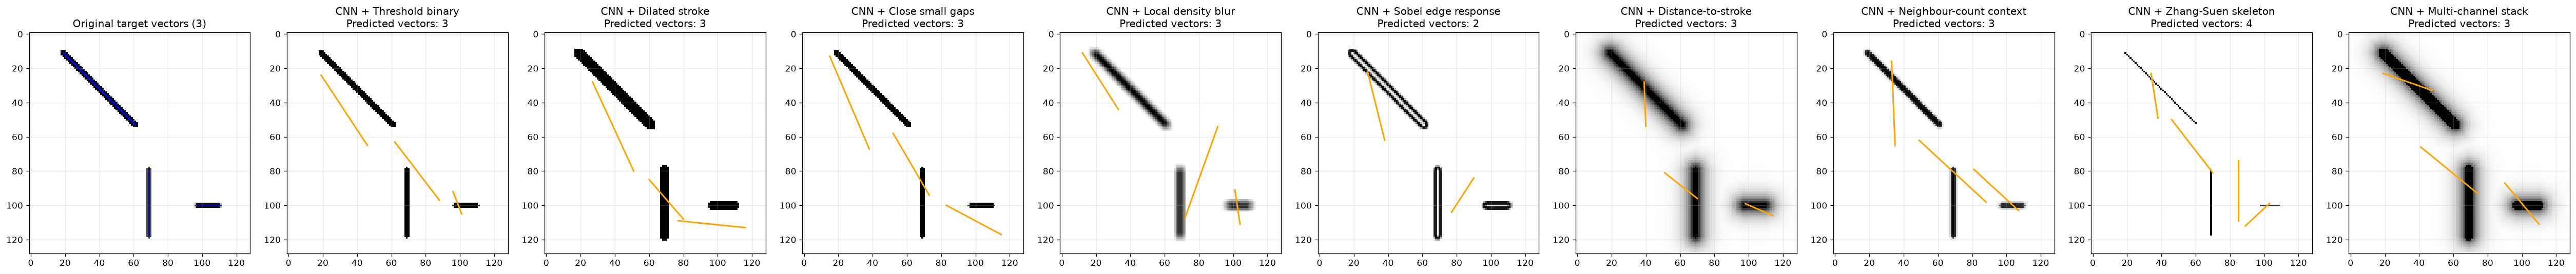

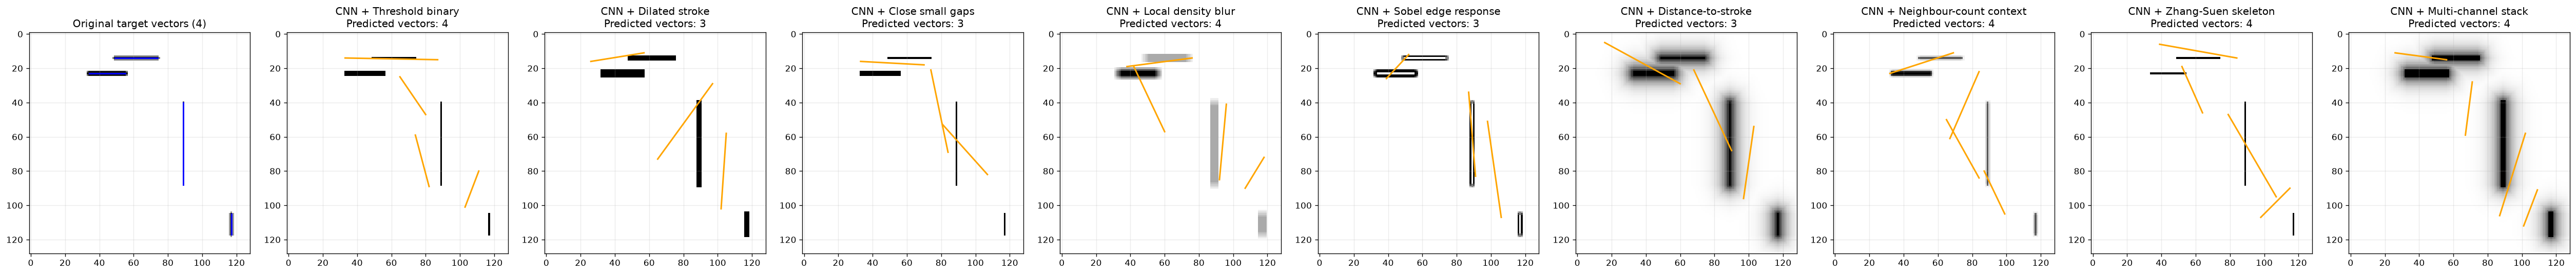

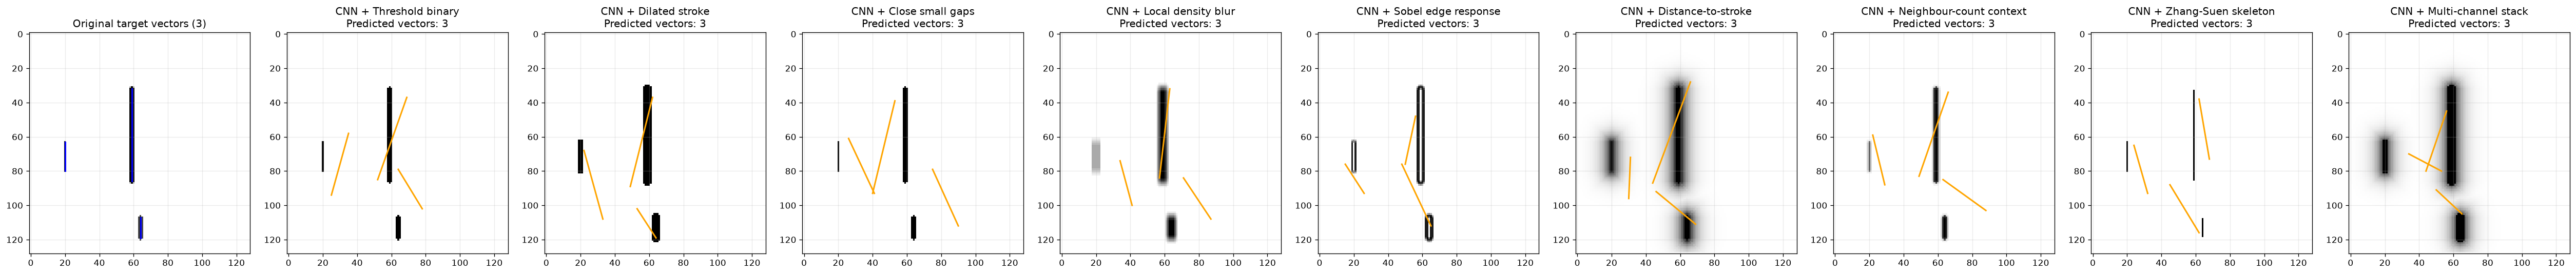

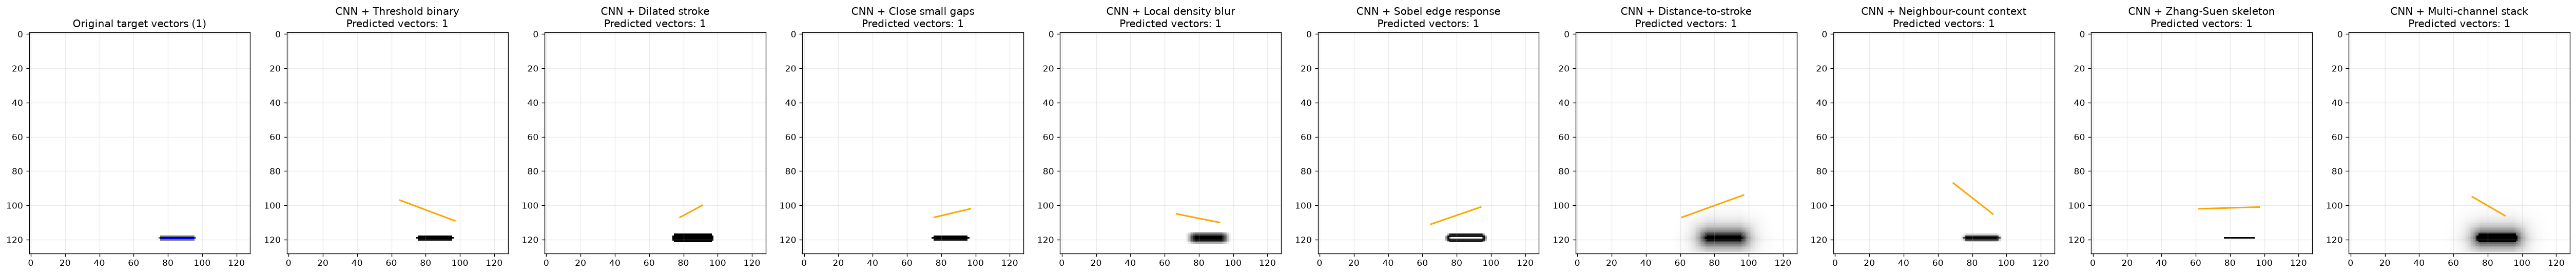

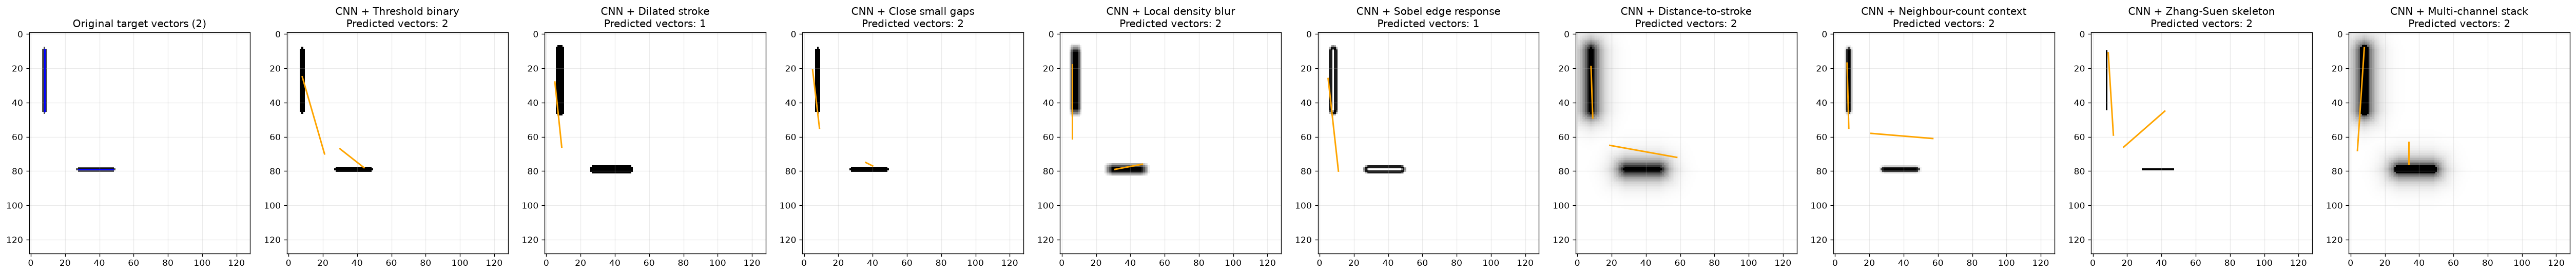

In [11]:
def draw_vectors(ax, image, vectors, title, colour='red'):
    ax.imshow(image, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    for x0, y0, x1, y1 in vectors:
        ax.plot([x0, x1], [y0, y1], color=colour, linewidth=1.8)
    ax.set_title(title)
    ax.set_xlim(-1, IMG_SIZE)
    ax.set_ylim(IMG_SIZE, -1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25)


NUM_PREVIEWS = 5          # Change this to 1, 3, 10, 20, etc.
START_SAMPLE_INDEX = 0    # First sample to preview

# Use this instead if you want exact sample numbers.
# Example: SAMPLE_INDICES = [0, 4, 12, 20]
SAMPLE_INDICES = None


PREVIEW_COLOURS = {
    'Original target vectors': 'blue',
    'cnn': 'orange',
}


def method_title(method_name):
    return METHOD_DISPLAY_NAMES.get(method_name, method_name.replace('_', ' '))


def show_method_comparison(sample_idx=0):
    raw_image = test_images[sample_idx]
    original_vectors = test_vectors[sample_idx]

    method_names = list(METHODS_TO_COMPARE.keys())
    ncols = 1 + len(method_names)

    fig, ax = plt.subplots(1, ncols, figsize=(4.2 * ncols, 4.6), dpi=120)
    ax = np.atleast_1d(ax)

    draw_vectors(
        ax[0],
        raw_image,
        original_vectors,
        f'Original target vectors ({len(original_vectors)})',
        PREVIEW_COLOURS['Original target vectors'],
    )

    for col, method_name in enumerate(method_names, start=1):
        preprocess_name = METHOD_PREPROCESS_LOOKUP[method_name]
        preprocessed_image = get_preprocess_display_image(preprocess_name, 'test', sample_idx)
        vectors = comparison_outputs[sample_idx][method_name]['vectors']
        draw_vectors(
            ax[col],
            preprocessed_image,
            vectors,
            f'{method_title(method_name)}\nPredicted vectors: {len(vectors)}',
            PREVIEW_COLOURS['cnn'],
        )

    plt.tight_layout()
    plt.show()


if SAMPLE_INDICES is None:
    SAMPLE_INDICES = range(START_SAMPLE_INDEX, START_SAMPLE_INDEX + NUM_PREVIEWS)

for idx in SAMPLE_INDICES:
    show_method_comparison(idx)

In [12]:
OUTPUT_DIR = Path(globals().get("OUTPUT_FOLDER_NAME", "cnn_preprocess_multichannel_comparison_results")) / "preview_images"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_cnn_preprocess_comparison_image(
    sample_indices=None,
    num_previews=10,
    start_sample_index=0,
    output_name="cnn_preprocess_samples_0_to_9",
    rows_per_image=2,
    dpi=220,
    cell_width=4.5,
    cell_height=4.5,
    show_after_saving=False,
):
    """
    Saves zoomable PNG comparison grids without freezing Jupyter.

    Instead of one enormous image, this saves chunks:
    - rows_per_image=1 gives one image per sample
    - rows_per_image=2 gives two samples per image
    - rows_per_image=5 gives five samples per image
    """

    if sample_indices is None:
        sample_indices = list(range(start_sample_index, start_sample_index + num_previews))
    else:
        sample_indices = list(sample_indices)

    method_names = list(METHODS_TO_COMPARE.keys())
    ncols = 1 + len(method_names)

    saved_files = []

    for chunk_start in range(0, len(sample_indices), rows_per_image):
        chunk = sample_indices[chunk_start:chunk_start + rows_per_image]
        nrows = len(chunk)

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(cell_width * ncols, cell_height * nrows),
            dpi=dpi,
            squeeze=False,
        )

        for row_idx, sample_idx in enumerate(chunk):
            raw_image = test_images[sample_idx]
            original_vectors = test_vectors[sample_idx]

            draw_vectors(
                axes[row_idx, 0],
                raw_image,
                original_vectors,
                f'Sample {sample_idx}\nOriginal target ({len(original_vectors)})',
                PREVIEW_COLOURS['Original target vectors'],
            )

            for col_idx, method_name in enumerate(method_names, start=1):
                preprocess_name = METHOD_PREPROCESS_LOOKUP[method_name]
                preprocessed_image = get_preprocess_display_image(preprocess_name, 'test', sample_idx)
                vectors = comparison_outputs[sample_idx][method_name]['vectors']

                draw_vectors(
                    axes[row_idx, col_idx],
                    preprocessed_image,
                    vectors,
                    f'{method_title(method_name)}\nPredicted {len(vectors)}',
                    PREVIEW_COLOURS['cnn'],
                )

        fig.tight_layout()

        if len(sample_indices) > rows_per_image:
            chunk_name = f"{output_name}_rows_{chunk_start:03d}_to_{chunk_start + nrows - 1:03d}.png"
        else:
            chunk_name = f"{output_name}.png"

        output_path = OUTPUT_DIR / chunk_name
        fig.savefig(output_path, bbox_inches='tight')
        saved_files.append(output_path)

        if show_after_saving:
            plt.show()
        else:
            plt.close(fig)

        print(f'Saved: {output_path}')

    return saved_files

In [13]:
save_cnn_preprocess_comparison_image(
    num_previews=10,
    start_sample_index=0,
    output_name="cnn_preprocess_multichannel_samples_0_to_9_large",
    rows_per_image=2,
    dpi=220,
    cell_width=4.5,
    cell_height=4.5,
    show_after_saving=False,
)

Saved: cnn_preprocess_multichannel_comparison_results\preview_images\cnn_preprocess_multichannel_samples_0_to_9_large_rows_000_to_001.png
Saved: cnn_preprocess_multichannel_comparison_results\preview_images\cnn_preprocess_multichannel_samples_0_to_9_large_rows_002_to_003.png
Saved: cnn_preprocess_multichannel_comparison_results\preview_images\cnn_preprocess_multichannel_samples_0_to_9_large_rows_004_to_005.png
Saved: cnn_preprocess_multichannel_comparison_results\preview_images\cnn_preprocess_multichannel_samples_0_to_9_large_rows_006_to_007.png
Saved: cnn_preprocess_multichannel_comparison_results\preview_images\cnn_preprocess_multichannel_samples_0_to_9_large_rows_008_to_009.png


[WindowsPath('cnn_preprocess_multichannel_comparison_results/preview_images/cnn_preprocess_multichannel_samples_0_to_9_large_rows_000_to_001.png'),
 WindowsPath('cnn_preprocess_multichannel_comparison_results/preview_images/cnn_preprocess_multichannel_samples_0_to_9_large_rows_002_to_003.png'),
 WindowsPath('cnn_preprocess_multichannel_comparison_results/preview_images/cnn_preprocess_multichannel_samples_0_to_9_large_rows_004_to_005.png'),
 WindowsPath('cnn_preprocess_multichannel_comparison_results/preview_images/cnn_preprocess_multichannel_samples_0_to_9_large_rows_006_to_007.png'),
 WindowsPath('cnn_preprocess_multichannel_comparison_results/preview_images/cnn_preprocess_multichannel_samples_0_to_9_large_rows_008_to_009.png')]

## Layered SVG export for CNN preprocessing inputs

In [14]:
from pathlib import Path
import re
import xml.etree.ElementTree as ET

SVG_NS = 'http://www.w3.org/2000/svg'
INKSCAPE_NS = 'http://www.inkscape.org/namespaces/inkscape'
ET.register_namespace('', SVG_NS)
ET.register_namespace('inkscape', INKSCAPE_NS)

LAYER_COLOURS = {
    'Original target vectors': '#1f77b4',
    'cnn': '#ff7f0e',
}


def safe_layer_id(name):
    return re.sub(r'[^A-Za-z0-9_\-]+', '_', name).strip('_').lower()


def add_line_layer(svg, layer_name, vectors, colour, stroke_width=1.0, visible=True):
    layer = ET.SubElement(svg, f'{{{SVG_NS}}}g', {
        'id': safe_layer_id(layer_name),
        f'{{{INKSCAPE_NS}}}groupmode': 'layer',
        f'{{{INKSCAPE_NS}}}label': layer_name,
        'stroke': colour,
        'stroke-width': str(stroke_width),
        'fill': 'none',
        'stroke-linecap': 'round',
        'stroke-linejoin': 'round',
        'style': 'display:inline' if visible else 'display:none',
    })

    ET.SubElement(layer, f'{{{SVG_NS}}}title').text = layer_name

    for x0, y0, x1, y1 in vectors:
        ET.SubElement(layer, f'{{{SVG_NS}}}line', {
            'x1': f'{x0:.3f}',
            'y1': f'{y0:.3f}',
            'x2': f'{x1:.3f}',
            'y2': f'{y1:.3f}',
        })

    return layer


def export_cnn_preprocess_svg(sample_idx=0, filename=None, include_background=True):
    if filename is None:
        filename = EXPORT_DIR / f'sample_{sample_idx}_cnn_preprocess_vector_comparison.svg'

    scale = 6

    svg = ET.Element(f'{{{SVG_NS}}}svg', {
        'width': str(IMG_SIZE * scale),
        'height': str(IMG_SIZE * scale),
        'viewBox': f'0 0 {IMG_SIZE} {IMG_SIZE}',
        'version': '1.1',
    })

    if include_background:
        background = ET.SubElement(svg, f'{{{SVG_NS}}}g', {
            'id': 'background',
            f'{{{INKSCAPE_NS}}}groupmode': 'layer',
            f'{{{INKSCAPE_NS}}}label': 'Background',
            'style': 'display:inline',
        })

        ET.SubElement(background, f'{{{SVG_NS}}}rect', {
            'x': '0',
            'y': '0',
            'width': str(IMG_SIZE),
            'height': str(IMG_SIZE),
            'fill': 'white',
        })

    add_line_layer(
        svg,
        'Original target vectors',
        test_vectors[sample_idx],
        LAYER_COLOURS['Original target vectors'],
        stroke_width=1.3,
    )

    for method_name in METHODS_TO_COMPARE.keys():
        add_line_layer(
            svg,
            METHOD_DISPLAY_NAMES.get(method_name, method_name),
            comparison_outputs[sample_idx][method_name]['vectors'],
            LAYER_COLOURS['cnn'],
            stroke_width=1.0,
        )

    filename = Path(filename)
    filename.parent.mkdir(parents=True, exist_ok=True)
    ET.ElementTree(svg).write(filename, encoding='utf-8', xml_declaration=True)

    print(f'Saved layered SVG: {filename}')
    return filename


NUM_OUTPUT_EXAMPLES = 10
SAMPLE_INDICES = None

if SAMPLE_INDICES is None:
    SAMPLE_INDICES = range(min(NUM_OUTPUT_EXAMPLES, len(test_images)))

exported_svgs = [
    export_cnn_preprocess_svg(i)
    for i in SAMPLE_INDICES
]

exported_svgs

Saved layered SVG: cnn_preprocess_multichannel_comparison_results\sample_0_cnn_preprocess_vector_comparison.svg
Saved layered SVG: cnn_preprocess_multichannel_comparison_results\sample_1_cnn_preprocess_vector_comparison.svg
Saved layered SVG: cnn_preprocess_multichannel_comparison_results\sample_2_cnn_preprocess_vector_comparison.svg
Saved layered SVG: cnn_preprocess_multichannel_comparison_results\sample_3_cnn_preprocess_vector_comparison.svg
Saved layered SVG: cnn_preprocess_multichannel_comparison_results\sample_4_cnn_preprocess_vector_comparison.svg
Saved layered SVG: cnn_preprocess_multichannel_comparison_results\sample_5_cnn_preprocess_vector_comparison.svg
Saved layered SVG: cnn_preprocess_multichannel_comparison_results\sample_6_cnn_preprocess_vector_comparison.svg
Saved layered SVG: cnn_preprocess_multichannel_comparison_results\sample_7_cnn_preprocess_vector_comparison.svg
Saved layered SVG: cnn_preprocess_multichannel_comparison_results\sample_8_cnn_preprocess_vector_compari

[WindowsPath('cnn_preprocess_multichannel_comparison_results/sample_0_cnn_preprocess_vector_comparison.svg'),
 WindowsPath('cnn_preprocess_multichannel_comparison_results/sample_1_cnn_preprocess_vector_comparison.svg'),
 WindowsPath('cnn_preprocess_multichannel_comparison_results/sample_2_cnn_preprocess_vector_comparison.svg'),
 WindowsPath('cnn_preprocess_multichannel_comparison_results/sample_3_cnn_preprocess_vector_comparison.svg'),
 WindowsPath('cnn_preprocess_multichannel_comparison_results/sample_4_cnn_preprocess_vector_comparison.svg'),
 WindowsPath('cnn_preprocess_multichannel_comparison_results/sample_5_cnn_preprocess_vector_comparison.svg'),
 WindowsPath('cnn_preprocess_multichannel_comparison_results/sample_6_cnn_preprocess_vector_comparison.svg'),
 WindowsPath('cnn_preprocess_multichannel_comparison_results/sample_7_cnn_preprocess_vector_comparison.svg'),
 WindowsPath('cnn_preprocess_multichannel_comparison_results/sample_8_cnn_preprocess_vector_comparison.svg'),
 WindowsPa